# Final Deliverable

**Author:** Stella Dong

*Department of Computer Science & Engineering, Texas A&M University*  
*This work was completed as part of CSCE 676: Data Mining and Analysis, taught by Prof. James Caverlee.*

The Github repository of this project can be found here: [Github link](https://github.com/stellasdong/676_project/).

--

In [1]:
import sys
print(sys.executable)
!pip install -r requirements.txt

/Users/stelladong/Documents/GitHub/676_project/.venv/bin/python


In [2]:
import warnings
warnings.filterwarnings('ignore')

import sys

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter, defaultdict

from icdmappings import Mapper
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder

from sklearn.preprocessing import MultiLabelBinarizer

# Reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

print('Imports complete.')


Imports complete.


In [3]:
DATA_PATH = "/Users/stelladong/Library/CloudStorage/GoogleDrive-ssdong@tamu.edu/My Drive/bcs_tx_inpatient.csv"

bcs_tx_inpatient = pd.read_csv(DATA_PATH, low_memory=False)
print(f"Loaded: {bcs_tx_inpatient.shape[0]:,} rows × {bcs_tx_inpatient.shape[1]} columns")

Loaded: 12,179 rows × 169 columns


In [4]:
df = bcs_tx_inpatient.copy()

# Identify diagnosis columns present in the dataframe
DIAG_COLS = [c for c in
             ['PRINC_DIAG_CODE'] + [f'OTH_DIAG_CODE_{i}' for i in range(1, 25)]
             if c in df.columns]

# Collect all unique ICD-10 codes across all diagnosis columns
all_codes = set()
for col in DIAG_COLS:
    all_codes.update(df[col].dropna().unique())
all_codes = list(all_codes)
print(f"Unique ICD-10 codes in dataset: {len(all_codes):,}")

BATCH_SIZE = 10000
mapper = Mapper()
ccsr_mapping = {}

for i in range(0, len(all_codes), BATCH_SIZE):
    batch = all_codes[i : i + BATCH_SIZE]
    results = mapper.map(batch, source='icd10', target='ccsr')
    for code, ccsr in zip(batch, results):
        ccsr_mapping[code] = ccsr  # None if unmappable

mapped = sum(1 for v in ccsr_mapping.values() if v is not None)
print(f"CCSR coverage: {mapped:,} / {len(ccsr_mapping):,} "
      f"({mapped / len(ccsr_mapping) * 100:.1f}%)")

Unique ICD-10 codes in dataset: 5,512
CCSR coverage: 5,512 / 5,512 (100.0%)


In [5]:
print(df.columns.tolist())

['Unnamed: 0', 'RECORD_ID', 'DISCHARGE', 'THCIC_ID', 'TYPE_OF_ADMISSION', 'SOURCE_OF_ADMISSION', 'SPEC_UNIT_1', 'SPEC_UNIT_2', 'SPEC_UNIT_3', 'SPEC_UNIT_4', 'SPEC_UNIT_5', 'PAT_STATE', 'PAT_ZIP', 'PAT_COUNTRY', 'PAT_COUNTY', 'PUBLIC_HEALTH_REGION', 'PAT_STATUS', 'SEX_CODE', 'RACE', 'ETHNICITY', 'ADMIT_WEEKDAY', 'LENGTH_OF_STAY', 'PAT_AGE', 'FIRST_PAYMENT_SRC', 'SECONDARY_PAYMENT_SRC', 'TYPE_OF_BILL', 'TOTAL_CHARGES', 'TOTAL_NON_COV_CHARGES', 'TOTAL_CHARGES_ACCOMM', 'TOTAL_NON_COV_CHARGES_ACCOMM', 'TOTAL_CHARGES_ANCIL', 'TOTAL_NON_COV_CHARGES_ANCIL', 'ADMITTING_DIAGNOSIS', 'PRINC_DIAG_CODE', 'POA_PRINC_DIAG_CODE', 'OTH_DIAG_CODE_1', 'POA_OTH_DIAG_CODE_1', 'OTH_DIAG_CODE_2', 'POA_OTH_DIAG_CODE_2', 'OTH_DIAG_CODE_3', 'POA_OTH_DIAG_CODE_3', 'OTH_DIAG_CODE_4', 'POA_OTH_DIAG_CODE_4', 'OTH_DIAG_CODE_5', 'POA_OTH_DIAG_CODE_5', 'OTH_DIAG_CODE_6', 'POA_OTH_DIAG_CODE_6', 'OTH_DIAG_CODE_7', 'POA_OTH_DIAG_CODE_7', 'OTH_DIAG_CODE_8', 'POA_OTH_DIAG_CODE_8', 'OTH_DIAG_CODE_9', 'POA_OTH_DIAG_CODE_9', '

In [6]:
# --- Association Rule Mining on CCSR comorbidities ---

# Build transactions: each patient is a "basket" of CCSR categories
def get_ccsr_set(row):
    cats = set()
    for col in DIAG_COLS:
        code = row[col]
        if pd.notna(code):
            ccsr = ccsr_mapping.get(code)
            if ccsr is not None:
                cats.add(ccsr)
    return list(cats)

ccsr_transactions = df.apply(get_ccsr_set, axis=1).tolist()
# Drop patients with no mappable codes
ccsr_transactions = [t for t in ccsr_transactions if len(t) > 0]
print(f"Transactions: {len(ccsr_transactions):,} patients")
print(f"Avg CCSR categories per patient: {np.mean([len(t) for t in ccsr_transactions]):.1f}")

# Encode as boolean DataFrame for mlxtend
te = TransactionEncoder()
te_array = te.fit_transform(ccsr_transactions)
df_te = pd.DataFrame(te_array, columns=te.columns_)
print(f"Item set size: {df_te.shape[1]} unique CCSR categories")

# --- Frequent itemsets (min_support tunable) ---
MIN_SUPPORT = 0.05   # at least 5% of patients
frequent_itemsets = apriori(df_te, min_support=MIN_SUPPORT, use_colnames=True)
frequent_itemsets['length'] = frequent_itemsets['itemsets'].apply(len)
print(f"\nFrequent itemsets (support ≥ {MIN_SUPPORT}): {len(frequent_itemsets):,}")
print(frequent_itemsets.sort_values('support', ascending=False).head(10).to_string(index=False))

# --- Association rules ---
MIN_CONFIDENCE = 0.5
rules = association_rules(frequent_itemsets, metric='confidence', min_threshold=MIN_CONFIDENCE)
rules = rules.sort_values('lift', ascending=False).reset_index(drop=True)
print(f"\nAssociation rules (confidence ≥ {MIN_CONFIDENCE}): {len(rules):,}")


Transactions: 12,179 patients
Avg CCSR categories per patient: 9.1
Item set size: 440 unique CCSR categories

Frequent itemsets (support ≥ 0.05): 306
 support         itemsets  length
0.496100         (FAC025)       1
0.377289         (FAC021)       1
0.296083         (END010)       1
0.271040 (FAC021, FAC025)       2
0.256507         (CIR007)       1
0.237376         (CIR008)       1
0.235816 (END010, FAC025)       2
0.196486 (CIR008, FAC025)       2
0.196157         (END009)       1
0.189342         (CIR011)       1

Association rules (confidence ≥ 0.5): 559


In [7]:
# --- Load CCSR descriptions ---
CCSR_DESC_PATH = "/Users/stelladong/Documents/GitHub/676_project/ccsr_descriptions.txt"

ccsr_desc = {}
with open(CCSR_DESC_PATH) as f:
    for line in f:
        parts = line.strip().split('\t')
        if len(parts) >= 2:
            ccsr_desc[parts[0]] = parts[1]

print(f"Loaded {len(ccsr_desc):,} CCSR descriptions")

def fmt_codes(frozen_set):
    return ' | '.join(f"{c} ({ccsr_desc.get(c, c)})" for c in sorted(frozen_set))

# Re-display top 30 rules with human-readable descriptions
top30 = (rules[rules['antecedents'].apply(len) == 1]
         .head(30)
         [['antecedents', 'consequents', 'support', 'confidence', 'lift']]
         .copy())

top30['antecedent_desc'] = top30['antecedents'].apply(fmt_codes)
top30['consequent_desc'] = top30['consequents'].apply(fmt_codes)

display_cols = ['antecedent_desc', 'consequent_desc', 'support', 'confidence', 'lift']
print("\nTop 30 comorbidity rules (single antecedent, ranked by lift):\n")
print(top30[display_cols].to_string(index=False))

Loaded 520 CCSR descriptions

Top 30 comorbidity rules (single antecedent, ranked by lift):

                                                            antecedent_desc                                                                                                                                consequent_desc  support  confidence     lift
                           PRG026 (OB-related trauma to perineum and vulva)                                                                             PRG002 (Gestational weeks) | PRG030 (Maternal outcome of delivery) 0.052549    0.993789 8.079676
                           PRG026 (OB-related trauma to perineum and vulva)                                                                                                          PRG030 (Maternal outcome of delivery) 0.052796    0.998447 8.074428
                                      PRG030 (Maternal outcome of delivery)                                                                PRG002 (Gestational w

In [8]:
# --- Export high-scoring comorbidity rules to CSV ---

# Fix CCSR description lookup: map code -> description
CCSR_DESC_PATH = "/Users/stelladong/Documents/GitHub/676_project/ccsr_descriptions.txt"
ccsr_desc_fixed = {}
with open(CCSR_DESC_PATH) as f:
    for line in f:
        parts = line.strip().split('\t')
        if len(parts) >= 2:
            ccsr_desc_fixed[parts[0]] = parts[1]

def describe_set(frozen_set):
    return ' | '.join(f"{c}: {ccsr_desc_fixed.get(c, c)}" for c in sorted(frozen_set))

# Filter to high-scoring rules: lift >= 2.0 (strong association)
HIGH_LIFT = 2.0
high_score_rules = rules[rules['lift'] >= HIGH_LIFT].copy()

# Flatten frozensets and add human-readable descriptions
high_score_rules['antecedent_codes']  = high_score_rules['antecedents'].apply(lambda s: ' | '.join(sorted(s)))
high_score_rules['antecedent_labels'] = high_score_rules['antecedents'].apply(describe_set)
high_score_rules['consequent_codes']  = high_score_rules['consequents'].apply(lambda s: ' | '.join(sorted(s)))
high_score_rules['consequent_labels'] = high_score_rules['consequents'].apply(describe_set)

export_cols = [
    'antecedent_codes', 'antecedent_labels',
    'consequent_codes', 'consequent_labels',
    'support', 'confidence', 'lift',
]
export_df = (high_score_rules[export_cols]
             .sort_values('lift', ascending=False)
             .reset_index(drop=True))

# Round metrics for readability
export_df[['support', 'confidence', 'lift']] = export_df[['support', 'confidence', 'lift']].round(4)

OUT_PATH = "/Users/stelladong/Documents/GitHub/676_project/comorbidity_rules.csv"
export_df.to_csv(OUT_PATH, index=False)

print(f"Exported {len(export_df):,} high-scoring rules (lift ≥ {HIGH_LIFT}) → {OUT_PATH}")
print(f"\nPreview (top 10):")
display(export_df.head(10))

Exported 346 high-scoring rules (lift ≥ 2.0) → /Users/stelladong/Documents/GitHub/676_project/comorbidity_rules.csv

Preview (top 10):


,antecedent_codes,antecedent_labels,consequent_codes,consequent_labels,support,confidence,lift
0,PRG002 | PRG026,PRG002: Gestational weeks | PRG026: OB-related...,PRG030,PRG030: Maternal outcome of delivery,0.0525,1.0000,8.0870
1,PRG026,PRG026: OB-related trauma to perineum and vulva,PRG002 | PRG030,PRG002: Gestational weeks | PRG030: Maternal o...,0.0525,0.9938,8.0797
2,PRG026,PRG026: OB-related trauma to perineum and vulva,PRG030,PRG030: Maternal outcome of delivery,0.0528,0.9984,8.0744
3,PRG002 | PRG023,PRG002: Gestational weeks | PRG023: Complicati...,PRG030,PRG030: Maternal outcome of delivery,0.0669,0.9927,8.0279
4,PRG030,PRG030: Maternal outcome of delivery,PRG002 | PRG023,PRG002: Gestational weeks | PRG023: Complicati...,0.0669,0.5412,8.0279
5,PRG023,PRG023: Complications specified during childbirth,PRG002 | PRG030,PRG002: Gestational weeks | PRG030: Maternal o...,0.0669,0.9855,8.0122
6,PRG002 | PRG030,PRG002: Gestational weeks | PRG030: Maternal o...,PRG023,PRG023: Complications specified during childbirth,0.0669,0.5441,8.0122
7,PRG030,PRG030: Maternal outcome of delivery,PRG023,PRG023: Complications specified during childbirth,0.0672,0.5438,8.0088
8,PRG023,PRG023: Complications specified during childbirth,PRG030,PRG030: Maternal outcome of delivery,0.0672,0.9903,8.0088
9,PNL001,PNL001: Liveborn,FAC016 | PNL007,"FAC016: Exposure, encounters, screening or con...",0.0874,0.7060,7.9989


In [9]:
# --- Export rules excluding those where PRG/PNL codes appear in BOTH antecedent AND consequent ---

def has_prg_or_pnl(frozen_set):
    return any(c.startswith('PRG') or c.startswith('PNL') for c in frozen_set)

# Exclude rules where ANY PRG/PNL code appears on both sides
mask = ~(high_score_rules['antecedents'].apply(has_prg_or_pnl) &
         high_score_rules['consequents'].apply(has_prg_or_pnl))

filtered_rules = high_score_rules[mask].copy()

export_df_filtered = (filtered_rules[export_cols]
                      .sort_values('lift', ascending=False)
                      .reset_index(drop=True))
export_df_filtered[['support', 'confidence', 'lift']] = export_df_filtered[['support', 'confidence', 'lift']].round(4)

OUT_PATH_FILTERED = "/Users/stelladong/Documents/GitHub/676_project/comorbidity_rules_no_prg_pnl.csv"
export_df_filtered.to_csv(OUT_PATH_FILTERED, index=False)

print(f"Original rules: {len(export_df):,}")
print(f"After excluding rules with PRG/PNL on both sides: {len(export_df_filtered):,} rules → {OUT_PATH_FILTERED}")
print(f"\nPreview (top 10):")
display(export_df_filtered.head(10))

Original rules: 346
After excluding rules with PRG/PNL on both sides: 323 rules → /Users/stelladong/Documents/GitHub/676_project/comorbidity_rules_no_prg_pnl.csv

Preview (top 10):


,antecedent_codes,antecedent_labels,consequent_codes,consequent_labels,support,confidence,lift
0,CIR008 | END003,CIR008: Hypertension with complications and se...,END010 | FAC025 | GEN003,END010: Disorders of lipid metabolism | FAC025...,0.0504,0.5121,6.0493
1,END010 | FAC025 | GEN003,END010: Disorders of lipid metabolism | FAC025...,CIR008 | END003,CIR008: Hypertension with complications and se...,0.0504,0.5955,6.0493
2,CIR019 | END010,CIR019: Heart failure | END010: Disorders of l...,CIR008 | CIR011 | FAC025,CIR008: Hypertension with complications and se...,0.0515,0.5806,5.9317
3,CIR008 | CIR011 | FAC025,CIR008: Hypertension with complications and se...,CIR019 | END010,CIR019: Heart failure | END010: Disorders of l...,0.0515,0.5260,5.9317
4,CIR019 | END010 | FAC025,CIR019: Heart failure | END010: Disorders of l...,CIR008 | CIR011,CIR008: Hypertension with complications and se...,0.0515,0.6786,5.9200
5,CIR019 | END010,CIR019: Heart failure | END010: Disorders of l...,CIR008 | CIR011,CIR008: Hypertension with complications and se...,0.0601,0.6778,5.9131
6,CIR008 | CIR011,CIR008: Hypertension with complications and se...,CIR019 | END010,CIR019: Heart failure | END010: Disorders of l...,0.0601,0.5244,5.9131
7,END010 | GEN003,END010: Disorders of lipid metabolism | GEN003...,CIR008 | END003,CIR008: Hypertension with complications and se...,0.0564,0.5682,5.7720
8,CIR008 | END003,CIR008: Hypertension with complications and se...,END010 | GEN003,END010: Disorders of lipid metabolism | GEN003...,0.0564,0.5730,5.7720
9,CIR008 | END003 | FAC025,CIR008: Hypertension with complications and se...,END010 | GEN003,END010: Disorders of lipid metabolism | GEN003...,0.0504,0.5680,5.7217


In [10]:
# --- Binary CCSR encoding ---
# For each patient (row), collect the set of CCSR categories present across
# all diagnosis columns, then one-hot encode into a binary matrix.

def get_ccsr_set(row):
    cats = set()
    for col in DIAG_COLS:
        code = row[col]
        if pd.notna(code):
            ccsr = ccsr_mapping.get(code)
            if ccsr is not None:
                cats.add(ccsr)
    return list(cats)

# Build list-of-lists: one entry per patient
ccsr_lists = df.apply(get_ccsr_set, axis=1).tolist()

# Fit MultiLabelBinarizer on all observed CCSR categories
mlb = MultiLabelBinarizer()
X_ccsr_binary = mlb.fit_transform(ccsr_lists)

print(f"Binary CCSR matrix shape: {X_ccsr_binary.shape}")
print(f"  Patients : {X_ccsr_binary.shape[0]:,}")
print(f"  CCSR categories : {X_ccsr_binary.shape[1]:,}")
print(f"  Sparsity: {1 - X_ccsr_binary.mean():.1%}")
print(f"\nCCSR category names (first 10): {mlb.classes_[:10].tolist()}")


Binary CCSR matrix shape: (12179, 440)
  Patients : 12,179
  CCSR categories : 440
  Sparsity: 97.9%

CCSR category names (first 10): ['BLD001', 'BLD002', 'BLD003', 'BLD004', 'BLD005', 'BLD006', 'BLD007', 'BLD008', 'BLD010', 'CIR001']


In [11]:
!pip install -q scikit-learn-extra

Computing Sørensen distance matrix...
Distance matrix shape: (12179, 12179)
k= 3  inertia=7,563.5658  silhouette=0.1056
k= 4  inertia=7,566.0928  silhouette=0.0814
k= 5  inertia=7,223.3816  silhouette=0.1001
k= 6  inertia=6,525.9373  silhouette=0.1562
k= 7  inertia=6,454.0657  silhouette=0.1243
k= 8  inertia=6,146.8609  silhouette=0.1944
k= 9  inertia=6,085.1942  silhouette=0.1763
k=10  inertia=6,054.3217  silhouette=0.1729
k=11  inertia=5,996.4494  silhouette=0.1662
k=12  inertia=5,935.6188  silhouette=0.1295


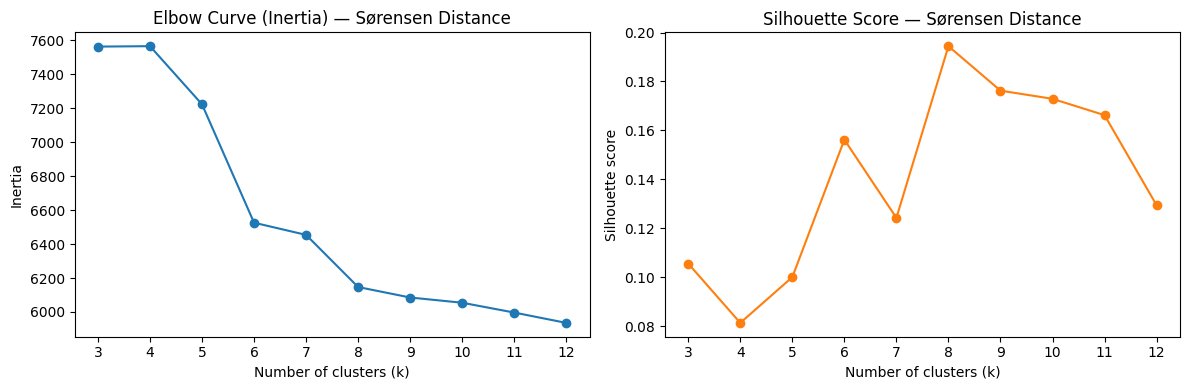

In [12]:
from sklearn_extra.cluster import KMedoids
from sklearn.metrics import silhouette_score
from scipy.spatial.distance import pdist, squareform

# Precompute full pairwise Sørensen (Dice) distance matrix once
print("Computing Sørensen distance matrix...")
sorensen_dist = squareform(pdist(X_ccsr_binary, metric='dice'))
print(f"Distance matrix shape: {sorensen_dist.shape}")

K_MIN = 3
K_MAX = 12

inertias = []
silhouette_scores = []
k_range = range(K_MIN, K_MAX + 1)

for k in k_range:
    km = KMedoids(n_clusters=k, metric='precomputed', random_state=RANDOM_SEED, init='k-medoids++')
    labels = km.fit_predict(sorensen_dist)
    inertias.append(km.inertia_)
    sil = silhouette_score(sorensen_dist, labels, metric='precomputed')
    silhouette_scores.append(sil)
    print(f"k={k:2d}  inertia={km.inertia_:,.4f}  silhouette={sil:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(list(k_range), inertias, marker='o')
axes[0].set_title('Elbow Curve (Inertia) — Sørensen Distance')
axes[0].set_xlabel('Number of clusters (k)')
axes[0].set_ylabel('Inertia')
axes[0].set_xticks(list(k_range))

axes[1].plot(list(k_range), silhouette_scores, marker='o', color='tab:orange')
axes[1].set_title('Silhouette Score — Sørensen Distance')
axes[1].set_xlabel('Number of clusters (k)')
axes[1].set_ylabel('Silhouette score')
axes[1].set_xticks(list(k_range))

plt.tight_layout()
plt.show()


## K-Medoids — Jaccard Distance

Computing Jaccard distance matrix...
Distance matrix shape: (12179, 12179)
k= 3  inertia=8,934.8522  silhouette=0.0729
k= 4  inertia=8,385.7376  silhouette=0.1150
k= 5  inertia=8,259.3307  silhouette=0.1123
k= 6  inertia=8,155.2152  silhouette=0.0985
k= 7  inertia=8,076.1560  silhouette=0.1032
k= 8  inertia=7,821.7424  silhouette=0.0989
k= 9  inertia=7,785.9848  silhouette=0.0979
k=10  inertia=7,521.1681  silhouette=0.1097
k=11  inertia=7,473.0768  silhouette=0.1101
k=12  inertia=7,436.1467  silhouette=0.0900


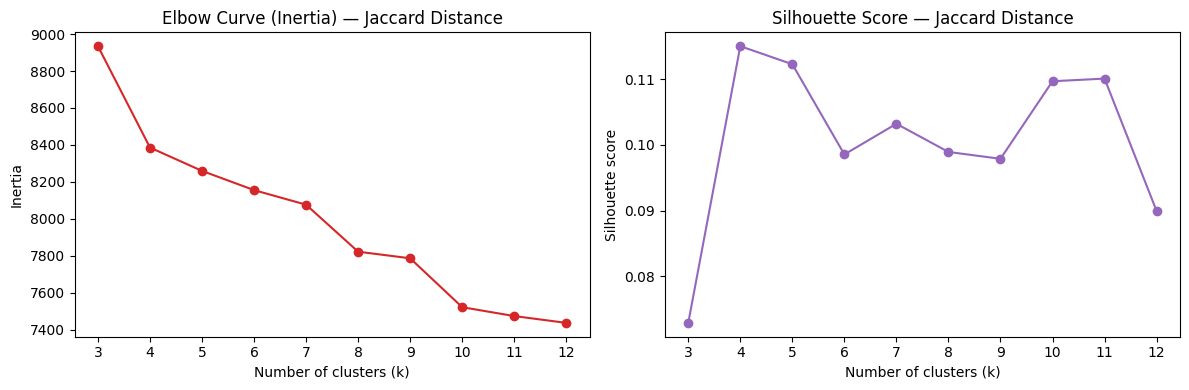

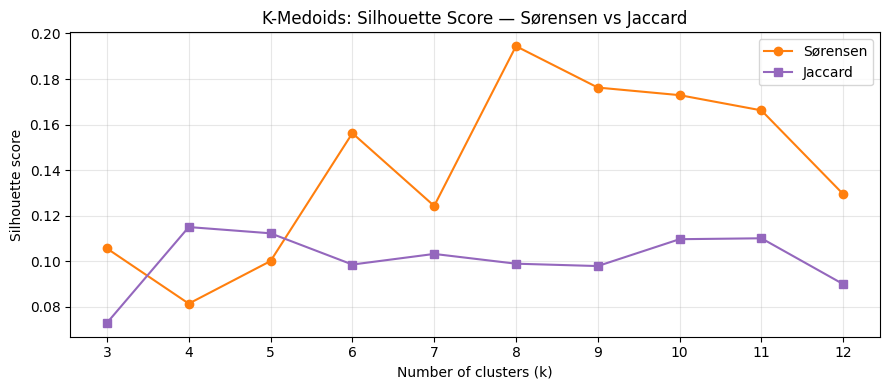

In [13]:
# Precompute Jaccard distance matrix
print("Computing Jaccard distance matrix...")
jaccard_dist = squareform(pdist(X_ccsr_binary, metric='jaccard'))
print(f"Distance matrix shape: {jaccard_dist.shape}")

K_MIN = 3
K_MAX = 12

inertias_jac = []
silhouette_scores_jac = []
k_range = range(K_MIN, K_MAX + 1)

for k in k_range:
    km = KMedoids(n_clusters=k, metric='precomputed', random_state=RANDOM_SEED, init='k-medoids++')
    labels = km.fit_predict(jaccard_dist)
    inertias_jac.append(km.inertia_)
    sil = silhouette_score(jaccard_dist, labels, metric='precomputed')
    silhouette_scores_jac.append(sil)
    print(f"k={k:2d}  inertia={km.inertia_:,.4f}  silhouette={sil:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(list(k_range), inertias_jac, marker='o', color='tab:red')
axes[0].set_title('Elbow Curve (Inertia) — Jaccard Distance')
axes[0].set_xlabel('Number of clusters (k)')
axes[0].set_ylabel('Inertia')
axes[0].set_xticks(list(k_range))

axes[1].plot(list(k_range), silhouette_scores_jac, marker='o', color='tab:purple')
axes[1].set_title('Silhouette Score — Jaccard Distance')
axes[1].set_xlabel('Number of clusters (k)')
axes[1].set_ylabel('Silhouette score')
axes[1].set_xticks(list(k_range))

plt.tight_layout()
plt.show()

# --- Compare Sørensen vs Jaccard silhouette side by side ---
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(list(k_range), silhouette_scores, marker='o', label='Sørensen', color='tab:orange')
ax.plot(list(k_range), silhouette_scores_jac, marker='s', label='Jaccard', color='tab:purple')
ax.set_title('K-Medoids: Silhouette Score — Sørensen vs Jaccard')
ax.set_xlabel('Number of clusters (k)')
ax.set_ylabel('Silhouette score')
ax.set_xticks(list(k_range))
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## DBSCAN — Sørensen Distance

eps=0.3  min_samples= 5  clusters=29  noise= 44.4%  silhouette=-0.0428
eps=0.3  min_samples=10  clusters= 9  noise= 49.4%  silhouette=0.0474
eps=0.3  min_samples=20  clusters=10  noise= 54.9%  silhouette=0.0986
eps=0.4  min_samples= 5  clusters= 8  noise= 13.8%  silhouette=0.0130
eps=0.4  min_samples=10  clusters= 5  noise= 16.7%  silhouette=0.0688
eps=0.4  min_samples=20  clusters= 3  noise= 20.1%  silhouette=0.1583
eps=0.5  min_samples= 5  clusters= 1  noise=  1.2%  silhouette=N/A
eps=0.5  min_samples=10  clusters= 1  noise=  1.5%  silhouette=N/A
eps=0.5  min_samples=20  clusters= 1  noise=  2.2%  silhouette=N/A
eps=0.6  min_samples= 5  clusters= 1  noise=  0.0%  silhouette=N/A
eps=0.6  min_samples=10  clusters= 1  noise=  0.1%  silhouette=N/A
eps=0.6  min_samples=20  clusters= 1  noise=  0.1%  silhouette=N/A
eps=0.7  min_samples= 5  clusters= 1  noise=  0.0%  silhouette=N/A
eps=0.7  min_samples=10  clusters= 1  noise=  0.0%  silhouette=N/A
eps=0.7  min_samples=20  clusters= 1  noise

,eps,min_samples,n_clusters,noise_pct,silhouette
0,0.4,20,3,20.116594,0.158334
1,0.3,20,10,54.881353,0.098598
2,0.4,10,5,16.717300,0.068837
3,0.3,10,9,49.421135,0.047402
4,0.4,5,8,13.802447,0.012951
5,0.3,5,29,44.404302,-0.042780
6,0.5,5,1,1.223417,NaN
7,0.5,10,1,1.469743,NaN
8,0.5,20,1,2.175877,NaN
9,0.6,5,1,0.049265,NaN


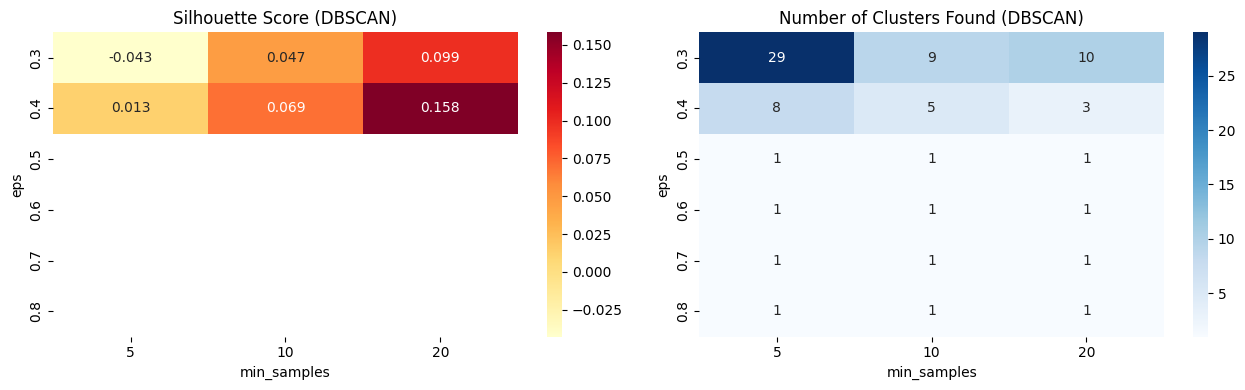

In [14]:
from sklearn.cluster import DBSCAN

# Sweep eps and min_samples; reuse sorensen_dist
eps_values = [0.3, 0.4, 0.5, 0.6, 0.7, 0.8]
min_samples_values = [5, 10, 20]

dbscan_results = []

for eps in eps_values:
    for min_samp in min_samples_values:
        db = DBSCAN(eps=eps, min_samples=min_samp, metric='precomputed', n_jobs=-1)
        labels = db.fit_predict(sorensen_dist)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = (labels == -1).sum()
        noise_pct = n_noise / len(labels) * 100
        sil = (silhouette_score(sorensen_dist, labels, metric='precomputed')
               if n_clusters >= 2 else float('nan'))
        dbscan_results.append({
            'eps': eps, 'min_samples': min_samp,
            'n_clusters': n_clusters, 'noise_pct': noise_pct, 'silhouette': sil
        })
        print(f"eps={eps}  min_samples={min_samp:2d}  "
              f"clusters={n_clusters:2d}  noise={noise_pct:5.1f}%  silhouette={sil:.4f}" if not np.isnan(sil)
              else f"eps={eps}  min_samples={min_samp:2d}  clusters={n_clusters:2d}  noise={noise_pct:5.1f}%  silhouette=N/A")

dbscan_df = pd.DataFrame(dbscan_results)
print("\nFull DBSCAN sweep results:")
display(dbscan_df.sort_values('silhouette', ascending=False).reset_index(drop=True))

# --- Heatmap of silhouette by eps × min_samples ---
pivot = dbscan_df.pivot(index='eps', columns='min_samples', values='silhouette')
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.heatmap(pivot, annot=True, fmt='.3f', cmap='YlOrRd', ax=axes[0])
axes[0].set_title('Silhouette Score (DBSCAN)')
axes[0].set_xlabel('min_samples')
axes[0].set_ylabel('eps')

pivot_k = dbscan_df.pivot(index='eps', columns='min_samples', values='n_clusters')
sns.heatmap(pivot_k, annot=True, fmt='d', cmap='Blues', ax=axes[1])
axes[1].set_title('Number of Clusters Found (DBSCAN)')
axes[1].set_xlabel('min_samples')
axes[1].set_ylabel('eps')

plt.tight_layout()
plt.show()

## HDBSCAN — Sørensen Distance

HDBSCAN results (best silhouette per unique cluster count):


,n_clusters,min_cluster_size,noise_pct,silhouette
0,9,190,43.230150,0.104651
1,11,160,40.224977,0.092865
2,15,140,38.976927,0.087505
3,18,120,39.067247,0.098904
4,22,110,35.249199,0.087543
5,23,100,34.419903,0.080912
6,24,90,33.656294,0.079496
7,25,80,34.107891,0.090003
8,31,70,31.234091,0.026734
9,37,60,28.105756,0.018410


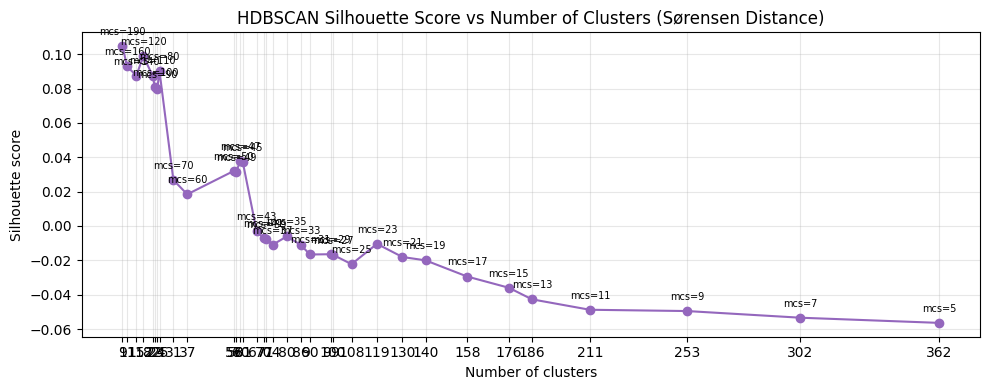

In [15]:
import hdbscan
from sklearn.metrics import silhouette_score

# Sweep min_cluster_size to get varying numbers of clusters (smaller = more clusters)
min_cluster_sizes = list(range(5, 50, 2)) + list(range(50, 200, 10))
min_samples = 5  # fix min_samples

seen_k = {}  # k -> best silhouette for that k

for mcs in min_cluster_sizes:
    clusterer = hdbscan.HDBSCAN(
        min_cluster_size=mcs,
        min_samples=min_samples,
        metric='precomputed',
        cluster_selection_method='eom'
    )
    labels = clusterer.fit_predict(sorensen_dist)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)

    if n_clusters < 3:
        continue

    mask = labels != -1
    if mask.sum() <= n_clusters:
        continue

    sil = silhouette_score(
        sorensen_dist[np.ix_(mask, mask)],
        labels[mask],
        metric='precomputed'
    )
    noise_pct = (labels == -1).sum() / len(labels) * 100

    # Keep best silhouette per unique k
    if n_clusters not in seen_k or sil > seen_k[n_clusters]['silhouette']:
        seen_k[n_clusters] = {
            'n_clusters': n_clusters,
            'min_cluster_size': mcs,
            'noise_pct': noise_pct,
            'silhouette': sil
        }

hdbscan_df = (pd.DataFrame(seen_k.values())
              .sort_values('n_clusters')
              .reset_index(drop=True))

print("HDBSCAN results (best silhouette per unique cluster count):")
display(hdbscan_df)

# --- Line plot: silhouette vs number of clusters ---
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(hdbscan_df['n_clusters'], hdbscan_df['silhouette'], marker='o', color='tab:purple')
for _, row in hdbscan_df.iterrows():
    ax.annotate(f"mcs={int(row.min_cluster_size)}",
                (row.n_clusters, row.silhouette),
                textcoords='offset points', xytext=(0, 8), fontsize=7, ha='center')
ax.set_title('HDBSCAN Silhouette Score vs Number of Clusters (Sørensen Distance)')
ax.set_xlabel('Number of clusters')
ax.set_ylabel('Silhouette score')
ax.set_xticks(hdbscan_df['n_clusters'])
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Hierarchical Clustering (Agglomerative) — Sørensen Distance


Linkage: complete
  k= 3  silhouette=-0.0415
  k= 4  silhouette=-0.0911
  k= 5  silhouette=-0.0736
  k= 6  silhouette=-0.0382
  k= 7  silhouette=-0.0735
  k= 8  silhouette=-0.0199
  k= 9  silhouette=-0.0516
  k=10  silhouette=-0.0572
  k=11  silhouette=-0.0575
  k=12  silhouette=-0.0613

Linkage: average
  k= 3  silhouette=0.1063
  k= 4  silhouette=0.1816
  k= 5  silhouette=0.1717
  k= 6  silhouette=0.1563
  k= 7  silhouette=0.1501
  k= 8  silhouette=0.1464
  k= 9  silhouette=0.1605
  k=10  silhouette=0.1557
  k=11  silhouette=0.2136
  k=12  silhouette=0.2090


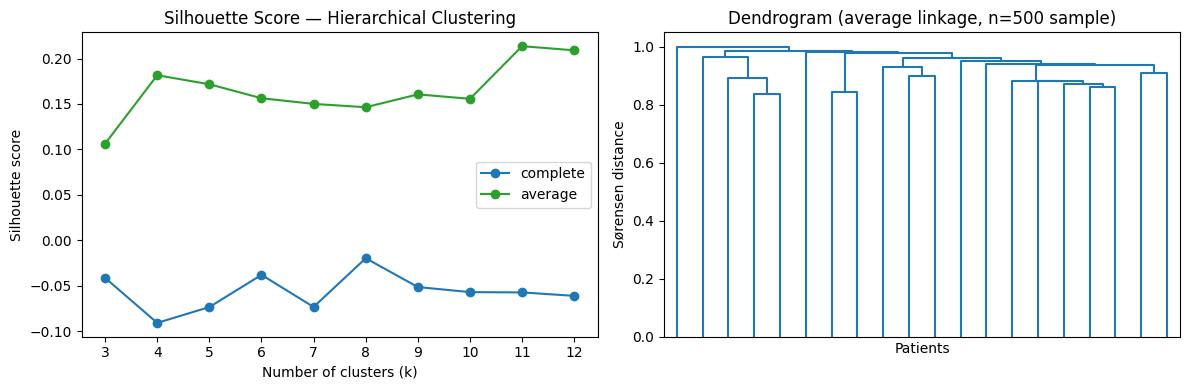

In [16]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage

# Reuse precomputed Sørensen distance matrix (sorensen_dist)
K_MIN, K_MAX = 3, 12
k_range = range(K_MIN, K_MAX + 1)

linkage_methods = ['ward', 'complete', 'average']
# Note: ward requires Euclidean; use complete/average with precomputed distances
results_hier = {m: {'silhouette': [], 'labels': {}} for m in ['complete', 'average']}

for method in ['complete', 'average']:
    print(f"\nLinkage: {method}")
    for k in k_range:
        agg = AgglomerativeClustering(
            n_clusters=k, metric='precomputed', linkage=method
        )
        labels = agg.fit_predict(sorensen_dist)
        sil = silhouette_score(sorensen_dist, labels, metric='precomputed')
        results_hier[method]['silhouette'].append(sil)
        results_hier[method]['labels'][k] = labels
        print(f"  k={k:2d}  silhouette={sil:.4f}")

# --- Plot ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
colors = {'complete': 'tab:blue', 'average': 'tab:green'}

for method in ['complete', 'average']:
    axes[0].plot(list(k_range), results_hier[method]['silhouette'],
                 marker='o', label=method, color=colors[method])

axes[0].set_title('Silhouette Score — Hierarchical Clustering')
axes[0].set_xlabel('Number of clusters (k)')
axes[0].set_ylabel('Silhouette score')
axes[0].set_xticks(list(k_range))
axes[0].legend()

# Dendrogram on a sample (full linkage is expensive on 11k patients)
SAMPLE_N = 500
np.random.seed(RANDOM_SEED)
sample_idx = np.random.choice(len(sorensen_dist), SAMPLE_N, replace=False)
sub_dist = sorensen_dist[np.ix_(sample_idx, sample_idx)]

Z = linkage(sub_dist[np.triu_indices(SAMPLE_N, k=1)], method='average')
dendrogram(Z, ax=axes[1], no_labels=True, truncate_mode='lastp', p=20, color_threshold=0.6*max(Z[:,2]))
axes[1].set_title(f'Dendrogram (average linkage, n={SAMPLE_N} sample)')
axes[1].set_xlabel('Patients')
axes[1].set_ylabel('Sørensen distance')

plt.tight_layout()
plt.show()

## K-Medoids on UMAP Embedding — Dimensionality Reduction


Fitting UMAP (n_components=2)...
  k= 3  inertia=61,692.4527  silhouette=0.4420
  k= 4  inertia=34,756.6607  silhouette=0.6410
  k= 5  inertia=25,637.9331  silhouette=0.5805
  k= 6  inertia=23,689.0113  silhouette=0.6232
  k= 7  inertia=20,793.4470  silhouette=0.6562
  k= 8  inertia=18,913.7122  silhouette=0.6684
  k= 9  inertia=18,522.2259  silhouette=0.6494
  k=10  inertia=17,830.0362  silhouette=0.6452
  k=11  inertia=16,785.5533  silhouette=0.6615
  k=12  inertia=16,113.7165  silhouette=0.5639

Fitting UMAP (n_components=5)...
  k= 3  inertia=44,308.3045  silhouette=0.7173
  k= 4  inertia=39,126.0333  silhouette=0.7500
  k= 5  inertia=29,737.8714  silhouette=0.6771
  k= 6  inertia=21,656.8313  silhouette=0.6487
  k= 7  inertia=20,697.7397  silhouette=0.6474
  k= 8  inertia=19,389.0468  silhouette=0.6661
  k= 9  inertia=18,066.5205  silhouette=0.6669
  k=10  inertia=16,173.2569  silhouette=0.6941
  k=11  inertia=15,722.9767  silhouette=0.6961
  k=12  inertia=14,998.8864  silhouette

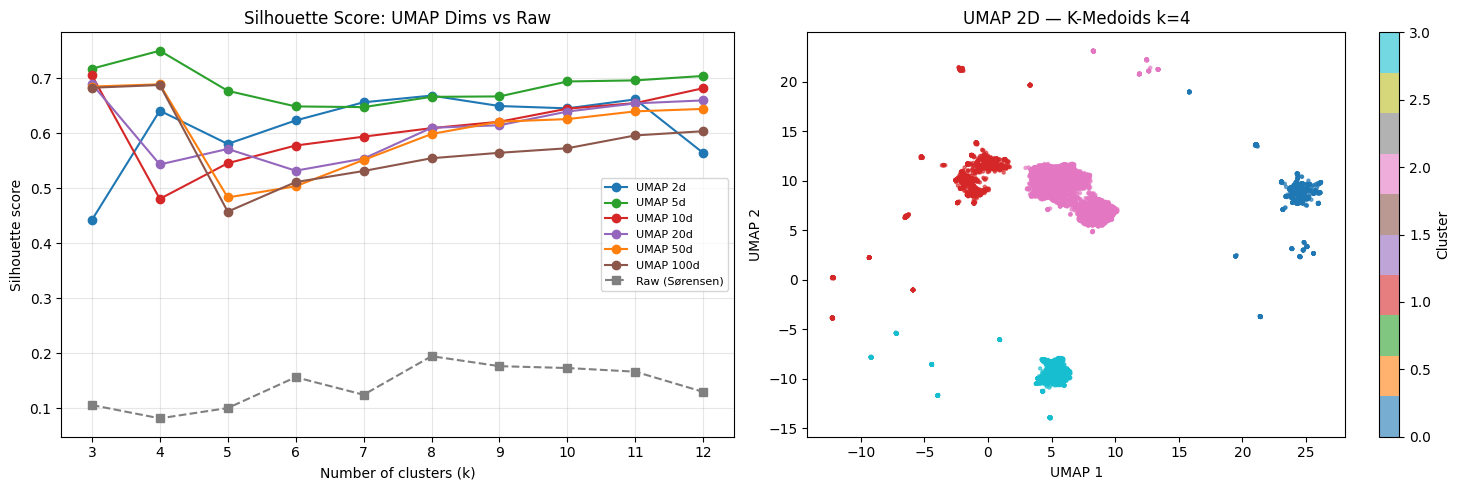


Best config: UMAP 5d, k=4, silhouette=0.7500
Raw Sørensen best: silhouette=0.1944 at k=8
Improvement: +0.5556

Top 20 CCSR categories per cluster (UMAP 5d, k=4)

Cluster 0  (n=1,072 patients, 8.8%)
  CCSR       Description                                   Prevalence
  -----------------------------------------------------------------
  PNL001     Liveborn                                           93.4%
  FAC016     Exposure, encounters, screening or contact w       90.8%
  PNL007     Hemolytic jaundice and perinatal jaundice          75.1%
  PNL013     Other specified and unspecified perinatal co       56.4%
  PNL002     Short gestation; low birth weight; and fetal       23.7%
  PNL010     Newborn affected by maternal conditions or c       19.7%
  PNL012     Neonatal digestive and feeding disorders           11.9%
  PNL008     Birth trauma                                       11.3%
  FAC003     Encounter for observation and examination fo       10.4%
  PNL005     Respiratory distress

In [17]:
import umap
from sklearn_extra.cluster import KMedoids
from sklearn.metrics import silhouette_score
from scipy.spatial.distance import pdist, squareform

# Original matrix has 400+ CCSR features.
# 2-20d is very aggressive; include 50 and 100 to better preserve variance.
umap_dims = [2, 5, 10, 20, 50, 100]
umap_results = {}

for n_comp in umap_dims:
    print(f"\nFitting UMAP (n_components={n_comp})...")
    reducer = umap.UMAP(
        n_components=n_comp,
        metric='jaccard',
        n_neighbors=15,
        min_dist=0.1,
        random_state=RANDOM_SEED
    )
    X_umap = reducer.fit_transform(X_ccsr_binary)

    # Replace any NaNs with column means (rare UMAP convergence issue)
    nan_mask = np.isnan(X_umap)
    if nan_mask.any():
        print(f"  Warning: {nan_mask.sum()} NaN values — imputing with column means")
        col_means = np.nanmean(X_umap, axis=0)
        X_umap[nan_mask] = np.take(col_means, np.where(nan_mask)[1])

    emb_dist = squareform(pdist(X_umap, metric='euclidean'))

    K_MIN, K_MAX = 3, 12
    k_range = range(K_MIN, K_MAX + 1)
    sils, inertias, all_labels = [], [], {}

    for k in k_range:
        km = KMedoids(n_clusters=k, metric='precomputed',
                      random_state=RANDOM_SEED, init='k-medoids++')
        labels = km.fit_predict(emb_dist)
        inertias.append(km.inertia_)
        sil = silhouette_score(emb_dist, labels, metric='precomputed')
        sils.append(sil)
        all_labels[k] = labels
        print(f"  k={k:2d}  inertia={km.inertia_:,.4f}  silhouette={sil:.4f}")

    umap_results[n_comp] = {
        'silhouette': sils, 'inertia': inertias,
        'embedding': X_umap, 'labels': all_labels
    }

k_range = range(K_MIN, K_MAX + 1)
colors = {2: 'tab:blue', 5: 'tab:green', 10: 'tab:red',
          20: 'tab:purple', 50: 'tab:orange', 100: 'tab:brown'}

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for n_comp in umap_dims:
    axes[0].plot(list(k_range), umap_results[n_comp]['silhouette'],
                 marker='o', label=f'UMAP {n_comp}d', color=colors[n_comp])
axes[0].plot(list(k_range), silhouette_scores,
             marker='s', linestyle='--', label='Raw (Sørensen)', color='gray')
axes[0].set_title('Silhouette Score: UMAP Dims vs Raw')
axes[0].set_xlabel('Number of clusters (k)')
axes[0].set_ylabel('Silhouette score')
axes[0].set_xticks(list(k_range))
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

# 2D scatter with k=4 clusters
X_2d = umap_results[2]['embedding']
labels_2d = umap_results[2]['labels'][4]
scatter = axes[1].scatter(X_2d[:, 0], X_2d[:, 1],
                           c=labels_2d, cmap='tab10', s=5, alpha=0.6)
axes[1].set_title('UMAP 2D — K-Medoids k=4')
axes[1].set_xlabel('UMAP 1')
axes[1].set_ylabel('UMAP 2')
plt.colorbar(scatter, ax=axes[1], label='Cluster')
plt.tight_layout()
plt.show()

# --- Find best config across all dims and k ---
best_sil, best_dim, best_k = -1, None, None
for n_comp in umap_dims:
    for i, sil in enumerate(umap_results[n_comp]['silhouette']):
        k = list(k_range)[i]
        if sil > best_sil:
            best_sil, best_dim, best_k = sil, n_comp, k

print(f"\nBest config: UMAP {best_dim}d, k={best_k}, silhouette={best_sil:.4f}")
print(f"Raw Sørensen best: silhouette={max(silhouette_scores):.4f} at k={list(k_range)[silhouette_scores.index(max(silhouette_scores))]}")
print(f"Improvement: {best_sil - max(silhouette_scores):+.4f}")

# --- Cluster interpretation: top CCSR codes per cluster ---
best_labels = umap_results[best_dim]['labels'][best_k]
ccsr_names = mlb.classes_  # CCSR category names from the binarizer

print(f"\n{'='*60}")
print(f"Top 20 CCSR categories per cluster (UMAP {best_dim}d, k={best_k})")
print(f"{'='*60}")

cluster_sizes = {}
for cluster_id in range(best_k):
    mask = best_labels == cluster_id
    cluster_sizes[cluster_id] = mask.sum()
    cluster_matrix = X_ccsr_binary[mask]  # patients in this cluster
    freq = cluster_matrix.mean(axis=0)    # prevalence of each CCSR in cluster
    top_idx = freq.argsort()[::-1][:20]

    print(f"\nCluster {cluster_id}  (n={mask.sum():,} patients, {mask.mean()*100:.1f}%)")
    print(f"  {'CCSR':<10} {'Description':<45} {'Prevalence':>10}")
    print(f"  {'-'*65}")
    for idx in top_idx:
        code = ccsr_names[idx]
        desc = ccsr_desc_fixed.get(code, code)[:44]
        print(f"  {code:<10} {desc:<45} {freq[idx]*100:>9.1f}%")

# --- Write cluster profiles to txt ---
OUT_TXT = "/Users/stelladong/Documents/GitHub/676_project/umap_cluster_profiles.txt"

with open(OUT_TXT, 'w') as f:
    f.write(f"UMAP Cluster Profiles\n")
    f.write(f"Configuration: UMAP {best_dim}d, k={best_k}, silhouette={best_sil:.4f}\n")
    f.write(f"{'='*65}\n")

    for cluster_id in range(best_k):
        mask = best_labels == cluster_id
        cluster_matrix = X_ccsr_binary[mask]
        freq = cluster_matrix.mean(axis=0)
        top_idx = freq.argsort()[::-1][:20]

        f.write(f"\nCluster {cluster_id}  (n={mask.sum():,} patients, {mask.mean()*100:.1f}%)\n")
        f.write(f"  {'CCSR':<10} {'Description':<50} {'Prevalence':>10}\n")
        f.write(f"  {'-'*70}\n")
        for idx in top_idx:
            code = ccsr_names[idx]
            desc = ccsr_desc_fixed.get(code, code)
            f.write(f"  {code:<10} {desc:<50} {freq[idx]*100:>9.1f}%\n")

print(f"Cluster profiles written to {OUT_TXT}")


---
## Experiment A: K-Medoids (Sørensen) — Excluding PRG/PNL Principal Diagnoses

Filter out any encounter whose **principal diagnosis** (`PRINC_DIAG_CODE`) maps to a PRG or PNL CCSR category, then re-run k-medoids with Sørensen distance to see if cleaner, non-obstetric clusters emerge.

In [18]:
# ── Experiment A: Filter rows where PRINC_DIAG_CODE → PRG or PNL CCSR ──

# Map each row's principal diagnosis to its CCSR category
princ_ccsr = df['PRINC_DIAG_CODE'].map(ccsr_mapping)

# Keep only rows whose principal diagnosis does NOT map to PRG or PNL
prg_pnl_mask = princ_ccsr.str.startswith('PRG', na=False) | princ_ccsr.str.startswith('PNL', na=False)
df_no_prg_pnl = df[~prg_pnl_mask].copy().reset_index(drop=True)

print(f"Original dataset:             {len(df):,} patients")
print(f"PRG/PNL principal dx removed: {prg_pnl_mask.sum():,} patients")
print(f"Remaining for clustering:     {len(df_no_prg_pnl):,} patients")

# Rebuild CCSR binary matrix for the filtered set
ccsr_lists_filt = df_no_prg_pnl.apply(get_ccsr_set, axis=1).tolist()

mlb_filt = MultiLabelBinarizer()
X_filt = mlb_filt.fit_transform(ccsr_lists_filt)

print(f"\nFiltered binary CCSR matrix: {X_filt.shape}")
print(f"  Patients      : {X_filt.shape[0]:,}")
print(f"  CCSR categories: {X_filt.shape[1]:,}")
print(f"  Sparsity       : {1 - X_filt.mean():.1%}")

Original dataset:             12,179 patients
PRG/PNL principal dx removed: 2,748 patients
Remaining for clustering:     9,431 patients

Filtered binary CCSR matrix: (9431, 428)
  Patients      : 9,431
  CCSR categories: 428
  Sparsity       : 97.6%


Computing Sørensen distance matrix for filtered set...
Distance matrix shape: (9431, 9431)
k= 3  inertia=6,017.9451  silhouette=0.0600
k= 4  inertia=5,940.7788  silhouette=0.0360
k= 5  inertia=5,747.3524  silhouette=0.0533
k= 6  inertia=5,670.8003  silhouette=0.0494
k= 7  inertia=5,595.7606  silhouette=0.0429
k= 8  inertia=5,222.8120  silhouette=0.0832
k= 9  inertia=5,158.9231  silhouette=0.0804
k=10  inertia=5,057.5272  silhouette=0.0687
k=11  inertia=4,857.9175  silhouette=0.0858
k=12  inertia=4,832.7198  silhouette=0.0777


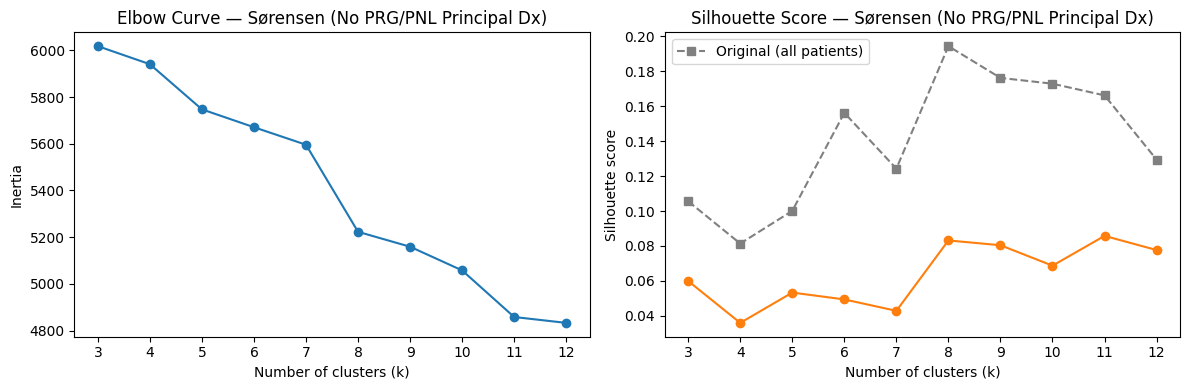


Best k (filtered): 11  silhouette=0.0858
Best k (original): 8  silhouette=0.1944


In [19]:
# ── K-Medoids sweep on filtered set (Sørensen) ──────────────────────

print("Computing Sørensen distance matrix for filtered set...")
sorensen_dist_filt = squareform(pdist(X_filt, metric='dice'))
print(f"Distance matrix shape: {sorensen_dist_filt.shape}")

K_MIN, K_MAX = 3, 12
k_range_filt = range(K_MIN, K_MAX + 1)

inertias_filt, sils_filt, labels_filt = [], [], {}

for k in k_range_filt:
    km = KMedoids(n_clusters=k, metric='precomputed',
                  random_state=RANDOM_SEED, init='k-medoids++')
    lbl = km.fit_predict(sorensen_dist_filt)
    labels_filt[k] = lbl
    inertias_filt.append(km.inertia_)
    sil = silhouette_score(sorensen_dist_filt, lbl, metric='precomputed')
    sils_filt.append(sil)
    print(f"k={k:2d}  inertia={km.inertia_:,.4f}  silhouette={sil:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(list(k_range_filt), inertias_filt, marker='o', color='tab:blue')
axes[0].set_title('Elbow Curve — Sørensen (No PRG/PNL Principal Dx)')
axes[0].set_xlabel('Number of clusters (k)')
axes[0].set_ylabel('Inertia')
axes[0].set_xticks(list(k_range_filt))

axes[1].plot(list(k_range_filt), sils_filt, marker='o', color='tab:orange')
# Overlay original for comparison
axes[1].plot(list(k_range_filt), silhouette_scores[:len(list(k_range_filt))],
             marker='s', linestyle='--', color='gray', label='Original (all patients)')
axes[1].set_title('Silhouette Score — Sørensen (No PRG/PNL Principal Dx)')
axes[1].set_xlabel('Number of clusters (k)')
axes[1].set_ylabel('Silhouette score')
axes[1].set_xticks(list(k_range_filt))
axes[1].legend()

plt.tight_layout()
plt.show()

best_k_filt = list(k_range_filt)[sils_filt.index(max(sils_filt))]
print(f"\nBest k (filtered): {best_k_filt}  silhouette={max(sils_filt):.4f}")
print(f"Best k (original): {list(k_range_filt)[silhouette_scores.index(max(silhouette_scores))]}  "
      f"silhouette={max(silhouette_scores):.4f}")

In [20]:
# ── Cluster profiles for best k on filtered set ──────────────────────

ccsr_names_filt = mlb_filt.classes_

lbl_best_filt = labels_filt[best_k_filt]
ccsr_df_filt = pd.DataFrame(X_filt, columns=ccsr_names_filt)
ccsr_df_filt['cluster'] = lbl_best_filt

cluster_profiles_filt = ccsr_df_filt.groupby('cluster').mean()

print(f"Cluster profiles (filtered, k={best_k_filt}):\n")
for c in range(best_k_filt):
    mask_c = lbl_best_filt == c
    top = cluster_profiles_filt.loc[c].nlargest(10)
    print(f"  Cluster {c}  (n={mask_c.sum():,}, {mask_c.mean()*100:.1f}%)")
    for code, val in top.items():
        desc = ccsr_desc_fixed.get(code, code)[:45]
        print(f"    {code:<10} {desc:<47} {val*100:5.1f}%")
    print()

Cluster profiles (filtered, k=11):

  Cluster 0  (n=1,866, 19.8%)
    FAC025     Other specified status                           77.3%
    CIR008     Hypertension with complications and secondary    71.9%
    FAC021     Personal/family history of disease               63.7%
    END010     Disorders of lipid metabolism                    58.4%
    CIR011     Coronary atherosclerosis and other heart dise    50.6%
    CIR019     Heart failure                                    48.9%
    CIR017     Cardiac dysrhythmias                             48.6%
    GEN003     Chronic kidney disease                           48.0%
    DIG004     Esophageal disorders                             42.5%
    END003     Diabetes mellitus with complication              30.3%

  Cluster 1  (n=347, 3.7%)
    MBD002     Depressive disorders                             90.5%
    MBD012     Suicidal ideation/attempt/intentional self-ha    67.7%
    NVS016     Sleep wake disorders                             46

### Experiment A — UMAP + K-Medoids on Filtered Set

Apply the same UMAP sweep (Jaccard metric, dims 2/5/10/20/50/100) to the PRG/PNL-filtered binary matrix, then run K-Medoids on each embedding. Compare against the raw Sørensen baseline from the filtered set.

Fitting UMAP (n_components=2) on filtered set...
  k= 3  inertia=27,742.6787  silhouette=0.6617
  k= 4  inertia=17,209.0694  silhouette=0.6150
  k= 5  inertia=14,596.8536  silhouette=0.6502
  k= 6  inertia=13,334.0766  silhouette=0.5098
  k= 7  inertia=12,167.5089  silhouette=0.5375
  k= 8  inertia=10,557.5085  silhouette=0.5647
  k= 9  inertia=9,365.9167  silhouette=0.5937
  k=10  inertia=8,634.7492  silhouette=0.4986
  k=11  inertia=8,147.1678  silhouette=0.4392
  k=12  inertia=7,710.4891  silhouette=0.4299
Fitting UMAP (n_components=5) on filtered set...
  k= 3  inertia=26,645.5347  silhouette=0.6275
  k= 4  inertia=23,510.9373  silhouette=0.6699
  k= 5  inertia=13,340.4493  silhouette=0.6762
  k= 6  inertia=12,490.6831  silhouette=0.4808
  k= 7  inertia=10,493.0222  silhouette=0.5355
  k= 8  inertia=9,635.1500  silhouette=0.5578
  k= 9  inertia=8,893.3103  silhouette=0.5058
  k=10  inertia=8,462.9538  silhouette=0.5186
  k=11  inertia=7,953.9738  silhouette=0.3743
  k=12  inertia=7

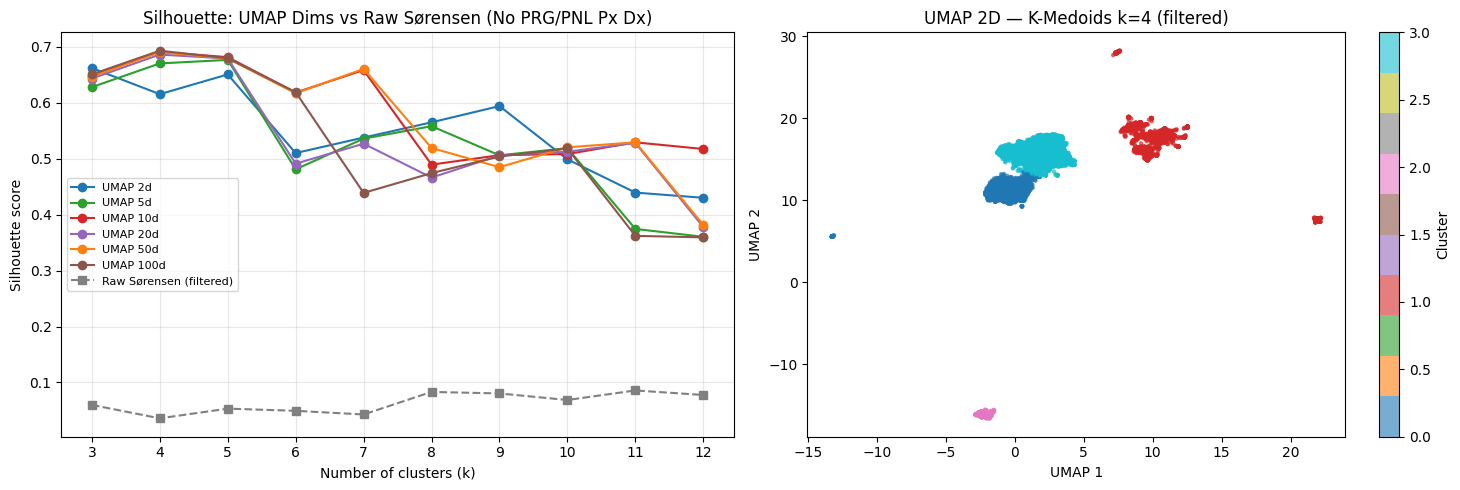

Best config (filtered): UMAP 100d, k=4, silhouette=0.6926
Raw Sørensen best (filtered): silhouette=0.0858 at k=11
Improvement: +0.6068


In [26]:
# ── UMAP sweep on filtered set (mirrors umap_code cell above) ───────────

umap_dims_filt = [2, 5, 10, 20, 50, 100]
umap_results_filt = {}
K_MIN_F, K_MAX_F = 3, 12
k_range_f = range(K_MIN_F, K_MAX_F + 1)

for n_comp in umap_dims_filt:
    print(f"Fitting UMAP (n_components={n_comp}) on filtered set...")
    reducer = umap.UMAP(
        n_components=n_comp,
        metric="jaccard",
        n_neighbors=15,
        min_dist=0.1,
        random_state=RANDOM_SEED
    )
    X_umap_f = reducer.fit_transform(X_filt)

    nan_mask = np.isnan(X_umap_f)
    if nan_mask.any():
        print(f"  Warning: {nan_mask.sum()} NaN values — imputing with column means")
        col_means = np.nanmean(X_umap_f, axis=0)
        X_umap_f[nan_mask] = np.take(col_means, np.where(nan_mask)[1])

    emb_dist_f = squareform(pdist(X_umap_f, metric="euclidean"))

    sils_f, inertias_f, all_labels_f = [], [], {}
    for k in k_range_f:
        km = KMedoids(n_clusters=k, metric="precomputed",
                      random_state=RANDOM_SEED, init="k-medoids++")
        lbl = km.fit_predict(emb_dist_f)
        inertias_f.append(km.inertia_)
        sil = silhouette_score(emb_dist_f, lbl, metric="precomputed")
        sils_f.append(sil)
        all_labels_f[k] = lbl
        print(f"  k={k:2d}  inertia={km.inertia_:,.4f}  silhouette={sil:.4f}")

    umap_results_filt[n_comp] = {
        "silhouette": sils_f, "inertia": inertias_f,
        "embedding": X_umap_f, "labels": all_labels_f
    }

colors_f = {2: "tab:blue", 5: "tab:green", 10: "tab:red",
            20: "tab:purple", 50: "tab:orange", 100: "tab:brown"}

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for n_comp in umap_dims_filt:
    axes[0].plot(list(k_range_f), umap_results_filt[n_comp]["silhouette"],
                 marker="o", label=f"UMAP {n_comp}d", color=colors_f[n_comp])
axes[0].plot(list(k_range_f), sils_filt,
             marker="s", linestyle="--", label="Raw Sørensen (filtered)", color="gray")
axes[0].set_title("Silhouette: UMAP Dims vs Raw Sørensen (No PRG/PNL Px Dx)")
axes[0].set_xlabel("Number of clusters (k)")
axes[0].set_ylabel("Silhouette score")
axes[0].set_xticks(list(k_range_f))
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

# 2D scatter with best k
best_sil_f, best_dim_f, best_k_f = -1, None, None
for n_comp in umap_dims_filt:
    for i, sil in enumerate(umap_results_filt[n_comp]["silhouette"]):
        k = list(k_range_f)[i]
        if sil > best_sil_f:
            best_sil_f, best_dim_f, best_k_f = sil, n_comp, k

X_2d_f = umap_results_filt[2]["embedding"]
lbl_2d_f = umap_results_filt[2]["labels"].get(best_k_f,
               umap_results_filt[2]["labels"][list(k_range_f)[0]])
scatter = axes[1].scatter(X_2d_f[:, 0], X_2d_f[:, 1],
                          c=lbl_2d_f, cmap="tab10", s=5, alpha=0.6)
axes[1].set_title(f"UMAP 2D — K-Medoids k={best_k_f} (filtered)")
axes[1].set_xlabel("UMAP 1")
axes[1].set_ylabel("UMAP 2")
plt.colorbar(scatter, ax=axes[1], label="Cluster")

plt.tight_layout()
plt.show()

print(f"Best config (filtered): UMAP {best_dim_f}d, k={best_k_f}, silhouette={best_sil_f:.4f}")
print(f"Raw Sørensen best (filtered): silhouette={max(sils_filt):.4f} at k={list(k_range_f)[sils_filt.index(max(sils_filt))]}")
print(f"Improvement: {best_sil_f - max(sils_filt):+.4f}")

In [32]:
# ── Cluster profiles for best UMAP config on filtered set ────────────────

best_labels_filt = umap_results_filt[best_dim_f]["labels"][best_k_f]

ccsr_df_filt_umap = pd.DataFrame(X_filt, columns=ccsr_names_filt)
ccsr_df_filt_umap["cluster"] = best_labels_filt
profiles_filt_umap = ccsr_df_filt_umap.groupby("cluster").mean()

OUT_TXT_A = "/Users/stelladong/Documents/GitHub/676_project/umap_cluster_profiles_no_prg_pnl.txt"

with open(OUT_TXT_A, "w") as fh:
    def w(s=""):
        print(s)
        fh.write(s + "\n")

    w("UMAP Cluster Profiles — PRG/PNL Principal Dx Excluded")
    w(f"Configuration: UMAP {best_dim_f}d, k={best_k_f}, silhouette={best_sil_f:.4f}")
    w("=" * 65)

    for c in range(best_k_f):
        mask_c = best_labels_filt == c
        top = profiles_filt_umap.loc[c].nlargest(10)
        w()
        w(f"Cluster {c}  (n={mask_c.sum():,}, {mask_c.mean()*100:.1f}%)")
        w(f"  {'CCSR':<10} {'Description':<50} {'Prevalence':>10}")
        w(f"  {'-'*70}")
        for code, val in top.items():
            desc = ccsr_desc_fixed.get(code, code)
            w(f"  {code:<10} {desc:<50} {val*100:>9.1f}%")

print(f"\nWritten to {OUT_TXT_A}")


UMAP Cluster Profiles — PRG/PNL Principal Dx ExcludedConfiguration: UMAP 100d, k=4, silhouette=0.6926=================================================================Cluster 0  (n=7,186, 76.2%)  CCSR       Description                                        Prevalence  ----------------------------------------------------------------------  FAC025     Other specified status                                  77.1%  FAC021     Personal/family history of disease                      56.4%  END010     Disorders of lipid metabolism                           49.2%  CIR007     Essential hypertension                                  38.7%  CIR008     Hypertension with complications and secondary hypertension      38.5%  CIR011     Coronary atherosclerosis and other heart disease        32.0%  END009     Obesity                                                 29.0%  DIG004     Esophageal disorders                                    28.8%  GEN003     Chronic kidney disease                          

---
## Experiment B: Sub-Cluster the Non-Pregnancy Cluster (UMAP 5D k=4 → K-Medoids Sørensen)

Use the UMAP 5D k=4 partition (already computed above) to identify the non-pregnancy / general-comorbidity cluster, then sub-cluster those patients with K-Medoids on the raw Sørensen distance matrix.

In [34]:
# ── Step B1: Identify the non-pregnancy cluster from UMAP 5D k=4 ──────

# Pull labels from the already-computed UMAP 5D, k=4 partition
UMAP_DIM_B, K_B = 5, 4
labels_umap5_k4 = umap_results[UMAP_DIM_B]["labels"][K_B]  # (n,) int 0-3

sil_umap5_k4 = silhouette_score(
    squareform(pdist(umap_results[UMAP_DIM_B]["embedding"], metric="euclidean")),
    labels_umap5_k4, metric="precomputed"
)
print(f"UMAP {UMAP_DIM_B}D, k={K_B}  →  silhouette={sil_umap5_k4:.4f}")

# Profile each cluster to identify the non-pregnancy one
ccsr_df_k4 = pd.DataFrame(X_ccsr_binary, columns=mlb.classes_)
ccsr_df_k4["cluster"] = labels_umap5_k4
profiles_k4 = ccsr_df_k4.groupby("cluster").mean()

# Cluster with the LOWEST mean PRG/PNL prevalence = non-pregnancy
prg_pnl_cols = [c for c in mlb.classes_ if c.startswith("PRG") or c.startswith("PNL")]
prg_pnl_frac = profiles_k4[prg_pnl_cols].mean(axis=1)

print("Mean PRG/PNL CCSR prevalence per cluster:")
for c in range(K_B):
    n = (labels_umap5_k4 == c).sum()
    print(f"  Cluster {c}  (n={n:,})  mean PRG/PNL prevalence = {prg_pnl_frac[c]:.4f}")

non_prg_cluster = int(prg_pnl_frac.idxmin())
print(f"→ Non-pregnancy cluster: Cluster {non_prg_cluster} "
      f"(n={int((labels_umap5_k4 == non_prg_cluster).sum()):,} patients)")

# Show top 10 codes for each cluster
print("Top 10 CCSR codes per cluster (UMAP 5D k=4):")
for c in range(K_B):
    top = profiles_k4.loc[c].nlargest(10)
    mask_c = labels_umap5_k4 == c
    print(f"Cluster {c}  (n={mask_c.sum():,}, {mask_c.mean()*100:.1f}%)")
    for code, val in top.items():
        desc = ccsr_desc_fixed.get(code, code)[:45]
        print(f"    {code:<10} {desc:<47} {val*100:5.1f}%")

UMAP 5D, k=4  →  silhouette=0.7500
Mean PRG/PNL CCSR prevalence per cluster:
  Cluster 0  (n=1,072)  mean PRG/PNL prevalence = 0.0840
  Cluster 1  (n=9,049)  mean PRG/PNL prevalence = 0.0001
  Cluster 2  (n=1,547)  mean PRG/PNL prevalence = 0.1102
  Cluster 3  (n=511)  mean PRG/PNL prevalence = 0.0440
→ Non-pregnancy cluster: Cluster 1 (n=9,049 patients)
Top 10 CCSR codes per cluster (UMAP 5D k=4):
Cluster 0  (n=1,072, 8.8%)
    PNL001     Liveborn                                         93.4%
    FAC016     Exposure, encounters, screening or contact wi    90.8%
    PNL007     Hemolytic jaundice and perinatal jaundice        75.1%
    PNL013     Other specified and unspecified perinatal con    56.4%
    PNL002     Short gestation; low birth weight; and fetal     23.7%
    PNL010     Newborn affected by maternal conditions or co    19.7%
    PNL012     Neonatal digestive and feeding disorders         11.9%
    PNL008     Birth trauma                                     11.3%
    FAC003 

Sub-clustering 9,049 patients from Cluster 1 ...
  Raw Sørensen  k=2  silhouette=0.1639
  Raw Sørensen  k=3  silhouette=0.0838
  Raw Sørensen  k=4  silhouette=0.0609
  Raw Sørensen  k=5  silhouette=0.0790
  Raw Sørensen  k=6  silhouette=0.0982
  Raw Sørensen  k=7  silhouette=0.1130
  Raw Sørensen  k=8  silhouette=0.0703

Fitting UMAP (n_components=2) on sub-population...
  k=2  inertia=27,471.1576  silhouette=0.5910
  k=3  inertia=24,764.0790  silhouette=0.6310
  k=4  inertia=14,149.2557  silhouette=0.6385
  k=5  inertia=12,629.4580  silhouette=0.5050
  k=6  inertia=11,469.0760  silhouette=0.5301
  k=7  inertia=9,922.2643  silhouette=0.5234
  k=8  inertia=9,104.4629  silhouette=0.5415

Fitting UMAP (n_components=5) on sub-population...
  k=2  inertia=26,528.2439  silhouette=0.6275
  k=3  inertia=15,714.5182  silhouette=0.6237
  k=4  inertia=13,308.1015  silhouette=0.6725
  k=5  inertia=12,489.2627  silhouette=0.6897
  k=6  inertia=11,640.6339  silhouette=0.5080
  k=7  inertia=10,487.03

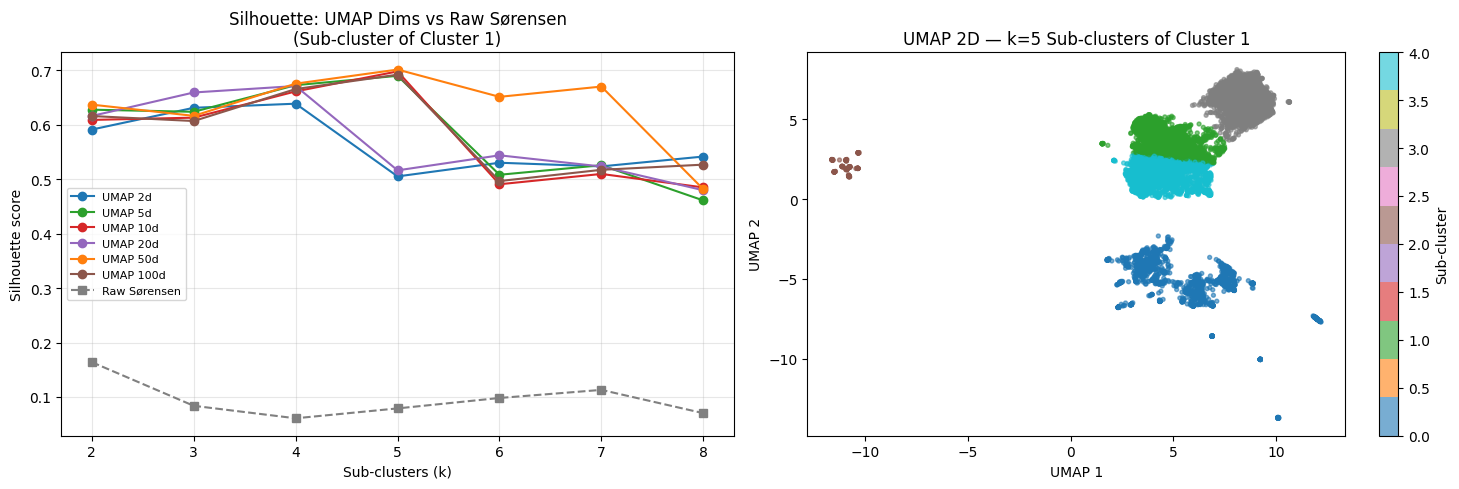


Best config: UMAP 50d, k=5, silhouette=0.7012
Raw Sørensen best: silhouette=0.1639 at k=2


In [35]:
# ── Step B2: UMAP sweep on the non-pregnancy sub-population ──────────

# Extract patients in the non-pregnancy cluster
non_prg_idx = np.where(labels_umap5_k4 == non_prg_cluster)[0]
X_sub = X_ccsr_binary[non_prg_idx]
print(f"Sub-clustering {len(non_prg_idx):,} patients from Cluster {non_prg_cluster} ...")

# Also slice Sørensen for reference baseline
sorensen_sub = sorensen_dist[np.ix_(non_prg_idx, non_prg_idx)]

# --- Raw Sørensen baseline (k=2..8) ---
K_MIN_SUB, K_MAX_SUB = 2, 8
k_range_sub = range(K_MIN_SUB, K_MAX_SUB + 1)

sils_sub_raw, inertias_sub_raw, labels_sub_raw = [], [], {}
for k in k_range_sub:
    km = KMedoids(n_clusters=k, metric="precomputed",
                  random_state=RANDOM_SEED, init="k-medoids++")
    lbl = km.fit_predict(sorensen_sub)
    labels_sub_raw[k] = lbl
    inertias_sub_raw.append(km.inertia_)
    sil = silhouette_score(sorensen_sub, lbl, metric="precomputed")
    sils_sub_raw.append(sil)
    print(f"  Raw Sørensen  k={k}  silhouette={sil:.4f}")

# --- UMAP sweep on sub-population ---
umap_dims_sub = [2, 5, 10, 20, 50, 100]
umap_results_sub = {}
colors_sub = {2: "tab:blue", 5: "tab:green", 10: "tab:red",
              20: "tab:purple", 50: "tab:orange", 100: "tab:brown"}

for n_comp in umap_dims_sub:
    print(f"\nFitting UMAP (n_components={n_comp}) on sub-population...")
    reducer = umap.UMAP(
        n_components=n_comp,
        metric="jaccard",
        n_neighbors=15,
        min_dist=0.1,
        random_state=RANDOM_SEED
    )
    X_umap_sub = reducer.fit_transform(X_sub)

    nan_mask = np.isnan(X_umap_sub)
    if nan_mask.any():
        print(f"  Warning: {nan_mask.sum()} NaN values — imputing with column means")
        col_means = np.nanmean(X_umap_sub, axis=0)
        X_umap_sub[nan_mask] = np.take(col_means, np.where(nan_mask)[1])

    emb_dist_sub = squareform(pdist(X_umap_sub, metric="euclidean"))

    sils_s, inertias_s, labels_s = [], [], {}
    for k in k_range_sub:
        km = KMedoids(n_clusters=k, metric="precomputed",
                      random_state=RANDOM_SEED, init="k-medoids++")
        lbl = km.fit_predict(emb_dist_sub)
        labels_s[k] = lbl
        inertias_s.append(km.inertia_)
        sil = silhouette_score(emb_dist_sub, lbl, metric="precomputed")
        sils_s.append(sil)
        print(f"  k={k}  inertia={km.inertia_:,.4f}  silhouette={sil:.4f}")

    umap_results_sub[n_comp] = {
        "silhouette": sils_s, "inertia": inertias_s,
        "embedding": X_umap_sub, "labels": labels_s
    }

# --- Plots ---
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for n_comp in umap_dims_sub:
    axes[0].plot(list(k_range_sub), umap_results_sub[n_comp]["silhouette"],
                 marker="o", label=f"UMAP {n_comp}d", color=colors_sub[n_comp])
axes[0].plot(list(k_range_sub), sils_sub_raw,
             marker="s", linestyle="--", color="gray", label="Raw Sørensen")
axes[0].set_title(f"Silhouette: UMAP Dims vs Raw Sørensen\n(Sub-cluster of Cluster {non_prg_cluster})")
axes[0].set_xlabel("Sub-clusters (k)")
axes[0].set_ylabel("Silhouette score")
axes[0].set_xticks(list(k_range_sub))
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

# Find overall best config
best_sil_sub, best_dim_sub, best_k_sub = -1, None, None
for n_comp in umap_dims_sub:
    for i, sil in enumerate(umap_results_sub[n_comp]["silhouette"]):
        k = list(k_range_sub)[i]
        if sil > best_sil_sub:
            best_sil_sub, best_dim_sub, best_k_sub = sil, n_comp, k

# 2D scatter of best k on 2D embedding
X_2d_sub = umap_results_sub[2]["embedding"]
lbl_2d_sub = umap_results_sub[2]["labels"][best_k_sub]
scatter = axes[1].scatter(X_2d_sub[:, 0], X_2d_sub[:, 1],
                          c=lbl_2d_sub, cmap="tab10", s=8, alpha=0.6)
axes[1].set_title(f"UMAP 2D — k={best_k_sub} Sub-clusters of Cluster {non_prg_cluster}")
axes[1].set_xlabel("UMAP 1")
axes[1].set_ylabel("UMAP 2")
plt.colorbar(scatter, ax=axes[1], label="Sub-cluster")

plt.tight_layout()
plt.show()

print(f"\nBest config: UMAP {best_dim_sub}d, k={best_k_sub}, silhouette={best_sil_sub:.4f}")
print(f"Raw Sørensen best: silhouette={max(sils_sub_raw):.4f} at k={list(k_range_sub)[sils_sub_raw.index(max(sils_sub_raw))]}")


UMAP Sub-cluster Profiles — Non-Pregnancy Cluster 1
Configuration: UMAP 50d, k=5, silhouette=0.7012
Parent partition: UMAP 5D k=4 (Cluster 1, n=9,049 patients)

Sub-cluster 0  (n=1,572, 17.4%)
  CCSR       Description                                        Prevalence
  ----------------------------------------------------------------------
  MBD002     Depressive disorders                                    44.6%
  MBD003     Bipolar and related disorders                           28.3%
  MBD005     Anxiety and fear-related disorders                      25.8%
  MBD001     Schizophrenia spectrum and other psychotic disorders      21.6%
  FAC021     Personal/family history of disease                      19.5%
  MBD012     Suicidal ideation/attempt/intentional self-harm         17.9%
  CIR007     Essential hypertension                                  17.6%
  NVS016     Sleep wake disorders                                    15.5%
  MBD017     Alcohol-related disorders                   

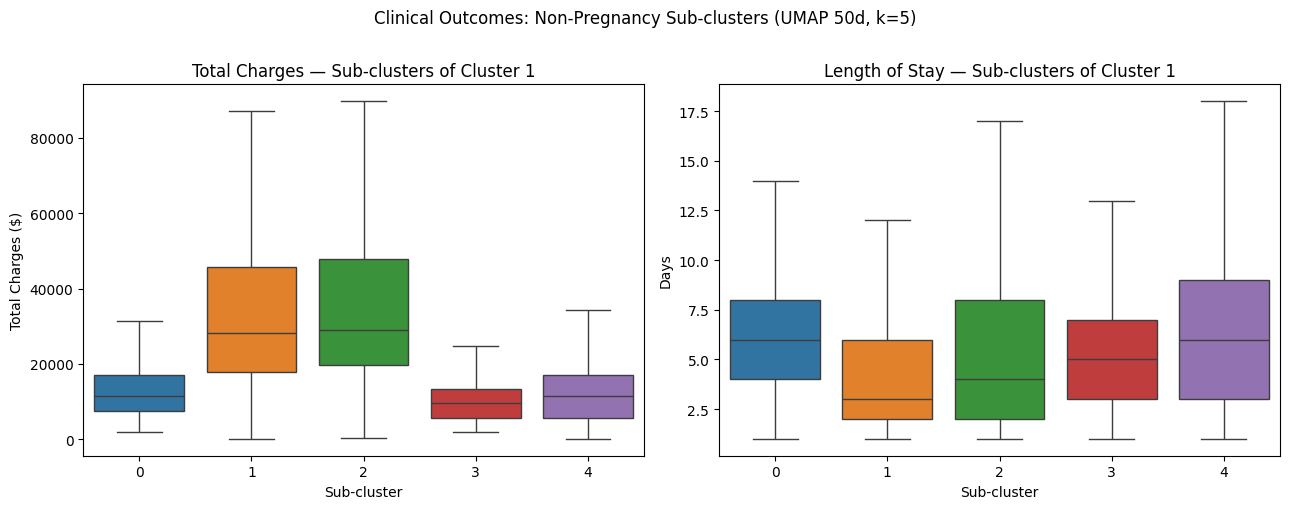

In [37]:
# ── Step B3: Profile the best UMAP sub-clusters ──────────────────────

lbl_sub_best = umap_results_sub[best_dim_sub]["labels"][best_k_sub]
ccsr_df_sub = pd.DataFrame(X_sub, columns=mlb.classes_)
ccsr_df_sub["subcluster"] = lbl_sub_best
profiles_sub = ccsr_df_sub.groupby("subcluster").mean()

OUT_TXT_B = "/Users/stelladong/Documents/GitHub/676_project/umap_subcluster_profiles_non_prg.txt"

with open(OUT_TXT_B, "w") as fh:
    def w(s=""):
        print(s)
        fh.write(s + "\n")

    w(f"UMAP Sub-cluster Profiles — Non-Pregnancy Cluster {non_prg_cluster}")
    w(f"Configuration: UMAP {best_dim_sub}d, k={best_k_sub}, silhouette={best_sil_sub:.4f}")
    w(f"Parent partition: UMAP 5D k=4 (Cluster {non_prg_cluster}, n={len(non_prg_idx):,} patients)")
    w("=" * 65)

    for sc in range(best_k_sub):
        mask_sc = lbl_sub_best == sc
        top = profiles_sub.loc[sc].nlargest(12)
        w()
        w(f"Sub-cluster {sc}  (n={mask_sc.sum():,}, {mask_sc.mean()*100:.1f}%)")
        w(f"  {'CCSR':<10} {'Description':<50} {'Prevalence':>10}")
        w(f"  {'-'*70}")
        for code, val in top.items():
            desc = ccsr_desc_fixed.get(code, code)
            w(f"  {code:<10} {desc:<50} {val*100:>9.1f}%")

print(f"\nWritten to {OUT_TXT_B}")

# --- Compare sub-cluster outcomes ---
LOS_COL_B    = next((c for c in ["LENGTH_OF_STAY", "LOS"] if c in df.columns), None)
CHARGE_COL_B = next((c for c in ["TOTAL_CHARGES", "CHARGES"] if c in df.columns), None)

sub_df_out = df.iloc[non_prg_idx][[CHARGE_COL_B, LOS_COL_B]].copy().reset_index(drop=True)
sub_df_out[CHARGE_COL_B] = pd.to_numeric(sub_df_out[CHARGE_COL_B], errors="coerce")
sub_df_out[LOS_COL_B]    = pd.to_numeric(sub_df_out[LOS_COL_B],    errors="coerce")
sub_df_out["subcluster"] = lbl_sub_best

sub_summary = sub_df_out.groupby("subcluster")[[CHARGE_COL_B, LOS_COL_B]].agg(["median", "mean"]).round(1)
print("Sub-cluster outcome summary:")
print(sub_summary.to_string())

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.boxplot(data=sub_df_out, x="subcluster", y=CHARGE_COL_B, ax=axes[0],
            palette="tab10", showfliers=False)
axes[0].set_title(f"Total Charges — Sub-clusters of Cluster {non_prg_cluster}")
axes[0].set_xlabel("Sub-cluster")
axes[0].set_ylabel("Total Charges ($)")

sns.boxplot(data=sub_df_out, x="subcluster", y=LOS_COL_B, ax=axes[1],
            palette="tab10", showfliers=False)
axes[1].set_title(f"Length of Stay — Sub-clusters of Cluster {non_prg_cluster}")
axes[1].set_xlabel("Sub-cluster")
axes[1].set_ylabel("Days")

plt.suptitle(f"Clinical Outcomes: Non-Pregnancy Sub-clusters (UMAP {best_dim_sub}d, k={best_k_sub})", y=1.01)
plt.tight_layout()
plt.show()


---
## Research Question 3: Which comorbidity subgroups predict high charges or longer LOS?

Pipeline:
1. Extract UMAP 5D, k=4 cluster labels (best-performing configuration)
2. Profile each cluster's dominant CCSR comorbidities
3. Compare clusters on TOTAL_CHARGES and LENGTH_OF_STAY
4. Log-linear regression (LassoCV) to identify comorbidity cost drivers
5. Report: cluster outcome summary + top comorbidity predictors


In [ ]:
# ── Step 1: Extract UMAP 5D k=4 labels (best config) ──────────────
BEST_DIM = 5
BEST_K   = 5

X_umap5      = umap_results[BEST_DIM]['embedding']            # (n, 5)
labels_umap4 = umap_results[BEST_DIM]['labels'][BEST_K]       # (n,) int 0–3
umap5_dist   = squareform(pdist(X_umap5, metric='euclidean'))  # pairwise dist

# Attach to df
df['cluster'] = labels_umap4

sil = silhouette_score(umap5_dist, labels_umap4, metric='precomputed')
print(f'UMAP {BEST_DIM}D, k={BEST_K}  →  silhouette = {sil:.4f}')
print(f'Cluster counts:')
print(pd.Series(labels_umap4).value_counts().sort_index().to_string())


UMAP 5D, k=5  →  silhouette = 0.6771
Cluster counts:
0    1072
1    7192
2    1547
3     511
4    1857


In [ ]:
# ── Step 2: Cluster comorbidity profiles ───────────────────────────
ccsr_names = mlb.classes_

ccsr_df = pd.DataFrame(X_ccsr_binary, columns=ccsr_names)
ccsr_df['cluster'] = labels_umap4

# Mean prevalence of each CCSR code per cluster
cluster_profiles = ccsr_df.groupby('cluster').mean()  # (4, n_ccsr)

# Chi-squared test to find most cluster-discriminating CCSR codes
from scipy.stats import chi2_contingency

disc_scores = {}
for col in ccsr_names:
    ct = pd.crosstab(ccsr_df[col], ccsr_df['cluster'])
    if ct.shape == (2, BEST_K):   # need both 0/1 present and all clusters
        chi2, p, *_ = chi2_contingency(ct)
        disc_scores[col] = (chi2, p)

disc_df = (pd.DataFrame(disc_scores, index=['chi2', 'p']).T
             .sort_values('chi2', ascending=False))

print(f'Top 20 cluster-discriminating CCSR codes (chi-squared):')
print(disc_df.head(20).to_string())

print(f'\nTop 10 comorbidities per cluster (by prevalence):')
for c in range(BEST_K):
    top = cluster_profiles.loc[c].nlargest(10)
    desc_list = [(code, ccsr_desc_fixed.get(code, code)[:40], f'{v*100:.1f}%')
                 for code, v in top.items()]
    print(f'\n  Cluster {c} (n={int((labels_umap4==c).sum()):,}):')
    for code, desc, pct in desc_list:
        print(f'    {code:<10} {desc:<42} {pct}')


Top 20 cluster-discriminating CCSR codes (chi-squared):
                chi2    p
PRG002  11999.022849  0.0
PRG030  11810.675766  0.0
PNL001  11521.885822  0.0
PNL007   8530.506797  0.0
FAC016   7415.047946  0.0
PNL013   6583.658268  0.0
PRG023   6097.747149  0.0
FAC025   5623.377706  0.0
PRG026   4673.094389  0.0
PRG024   4284.078834  0.0
END010   3246.173937  0.0
FAC021   2698.886389  0.0
PNL002   2675.402809  0.0
MBD001   2286.519283  0.0
PNL010   2212.413806  0.0
CIR008   2147.143205  0.0
PRG016   2092.199943  0.0
CIR011   1943.446141  0.0
FAC024   1844.162671  0.0
MBD003   1776.371560  0.0

Top 10 comorbidities per cluster (by prevalence):

  Cluster 0 (n=1,072):
    PNL001     Liveborn                                   93.4%
    FAC016     Exposure, encounters, screening or conta   90.8%
    PNL007     Hemolytic jaundice and perinatal jaundic   75.1%
    PNL013     Other specified and unspecified perinata   56.4%
    PNL002     Short gestation; low birth weight; and f   23.7%
   

Outcome columns — charges: TOTAL_CHARGES, LOS: LENGTH_OF_STAY

Kruskal-Wallis TOTAL_CHARGES:   H=5483.9, p=0.00e+00
Kruskal-Wallis LENGTH_OF_STAY:  H=1973.6, p=0.00e+00

Cluster outcome summary:
        TOTAL_CHARGES          LENGTH_OF_STAY     
               median     mean         median mean
cluster                                           
0              5413.3  13011.5            2.0  3.8
1             28586.7  38300.6            3.0  5.2
2             12794.0  14323.0            2.0  2.2
3              3248.7   3934.4            2.0  1.7
4             11400.0  14007.2            6.0  6.8


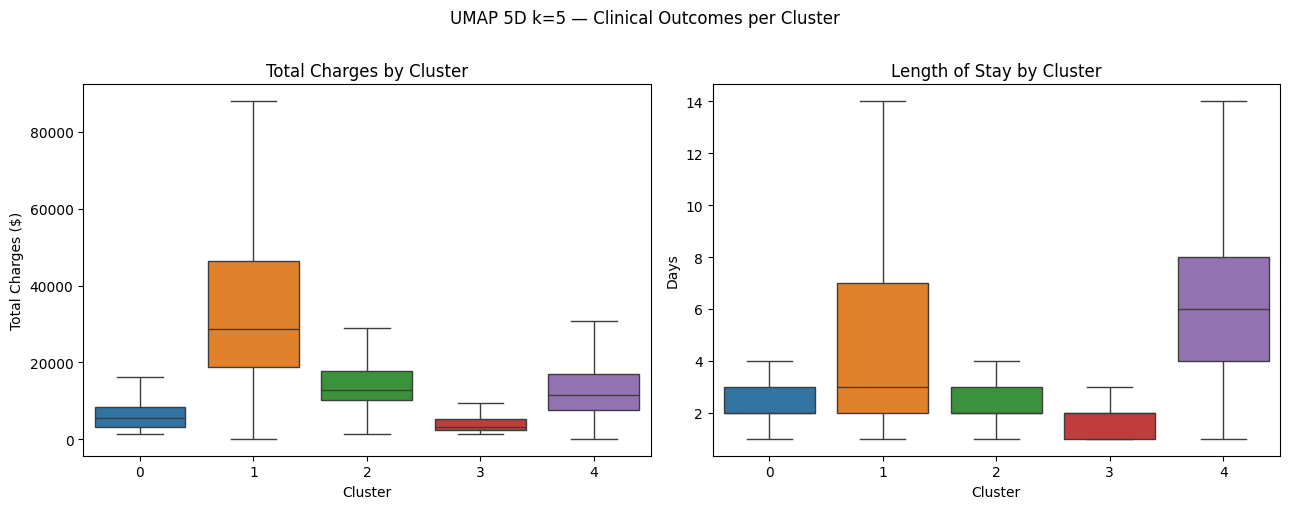

In [ ]:
# ── Step 3: Compare clusters on TOTAL_CHARGES and LENGTH_OF_STAY ───
from scipy.stats import kruskal

LOS_COL    = next((c for c in ['LENGTH_OF_STAY', 'LOS'] if c in df.columns), None)
CHARGE_COL = next((c for c in ['TOTAL_CHARGES', 'CHARGES'] if c in df.columns), None)

print(f'Outcome columns — charges: {CHARGE_COL}, LOS: {LOS_COL}')

df_out = df[['cluster', CHARGE_COL, LOS_COL]].copy()
df_out[CHARGE_COL] = pd.to_numeric(df_out[CHARGE_COL], errors='coerce')
df_out[LOS_COL]    = pd.to_numeric(df_out[LOS_COL],    errors='coerce')

# Kruskal-Wallis (non-parametric — charges are right-skewed)
groups_chg = [df_out.loc[df_out.cluster==c, CHARGE_COL].dropna() for c in range(BEST_K)]
groups_los = [df_out.loc[df_out.cluster==c, LOS_COL].dropna()    for c in range(BEST_K)]
kw_chg = kruskal(*groups_chg)
kw_los = kruskal(*groups_los)

print(f'\nKruskal-Wallis TOTAL_CHARGES:   H={kw_chg.statistic:.1f}, p={kw_chg.pvalue:.2e}')
print(f'Kruskal-Wallis LENGTH_OF_STAY:  H={kw_los.statistic:.1f}, p={kw_los.pvalue:.2e}')

# Cluster-level outcome summary
summary = df_out.groupby('cluster')[[CHARGE_COL, LOS_COL]].agg(['median', 'mean']).round(1)
print('\nCluster outcome summary:')
print(summary.to_string())

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.boxplot(data=df_out, x='cluster', y=CHARGE_COL, ax=axes[0],
            palette='tab10', showfliers=False)
axes[0].set_title('Total Charges by Cluster')
axes[0].set_xlabel('Cluster')
axes[0].set_ylabel('Total Charges ($)')

sns.boxplot(data=df_out, x='cluster', y=LOS_COL, ax=axes[1],
            palette='tab10', showfliers=False)
axes[1].set_title('Length of Stay by Cluster')
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('Days')

plt.suptitle(f'UMAP {BEST_DIM}D k={BEST_K} — Clinical Outcomes per Cluster', y=1.01)
plt.tight_layout()
plt.show()


In [ ]:
# ── Step 4: Log-linear LassoCV — predict exact charges ─────────────
from sklearn.linear_model import LassoCV, Ridge
from sklearn.model_selection import cross_val_score, KFold
from sklearn.preprocessing import StandardScaler

# Drop rows where charges or LOS are missing
valid_mask = df_out[CHARGE_COL].notna() & df_out[LOS_COL].notna()
print(f'Valid rows for regression: {valid_mask.sum():,} / {len(valid_mask):,}')

# Log1p-transform targets (handles right skew + zero values)
y_chg = np.log1p(df_out.loc[valid_mask, CHARGE_COL].values)
y_los = np.log1p(df_out.loc[valid_mask, LOS_COL].values)

# Features: CCSR binary + cluster dummies
cluster_dummies = pd.get_dummies(labels_umap4[valid_mask], prefix='cluster',
                                  drop_first=True).values
X_feat = np.hstack([X_ccsr_binary[valid_mask].astype(float), cluster_dummies])

# Scale (with_mean=False to handle binary features safely)
scaler = StandardScaler(with_mean=False)
X_scaled = scaler.fit_transform(X_feat)

feature_names = list(ccsr_names) + [f'cluster_{i+1}' for i in range(BEST_K - 1)]

print(f'Feature matrix shape: {X_scaled.shape}')

# --- LassoCV for charges ---
print('\nFitting LassoCV for TOTAL_CHARGES...')
lasso_chg = LassoCV(cv=5, max_iter=10000, n_jobs=-1)
lasso_chg.fit(X_scaled, y_chg)
n_nonzero_chg = (lasso_chg.coef_ != 0).sum()
print(f'  alpha={lasso_chg.alpha_:.4f},  non-zero features={n_nonzero_chg}')

# --- LassoCV for LOS ---
print('\nFitting LassoCV for LENGTH_OF_STAY...')
lasso_los = LassoCV(cv=5, max_iter=10000, n_jobs=-1)
lasso_los.fit(X_scaled, y_los)
n_nonzero_los = (lasso_los.coef_ != 0).sum()
print(f'  alpha={lasso_los.alpha_:.4f},  non-zero features={n_nonzero_los}')

# --- Cross-validated R² (log scale) ---
r2_chg = cross_val_score(Ridge(alpha=10), X_scaled, y_chg, cv=5, scoring='r2')
r2_los = cross_val_score(Ridge(alpha=10), X_scaled, y_los, cv=5, scoring='r2')
print(f'\nRidge CV R² (log scale):')
print(f'  TOTAL_CHARGES:   {r2_chg.mean():.3f} ± {r2_chg.std():.3f}')
print(f'  LENGTH_OF_STAY:  {r2_los.mean():.3f} ± {r2_los.std():.3f}')

# --- Dollar-scale median absolute error ---
maes_chg, maes_los = [], []
for tr, te in KFold(5).split(X_scaled):
    m_c = LassoCV(cv=3, max_iter=5000)
    m_c.fit(X_scaled[tr], y_chg[tr])
    maes_chg.append(np.median(np.abs(np.expm1(m_c.predict(X_scaled[te])) -
                                      np.expm1(y_chg[te]))))
    m_l = LassoCV(cv=3, max_iter=5000)
    m_l.fit(X_scaled[tr], y_los[tr])
    maes_los.append(np.median(np.abs(np.expm1(m_l.predict(X_scaled[te])) -
                                      np.expm1(y_los[te]))))

print(f'\nMedian absolute error (original scale):')
print(f'  TOTAL_CHARGES:   ${np.mean(maes_chg):,.0f}')
print(f'  LENGTH_OF_STAY:  {np.mean(maes_los):.2f} days')


Valid rows for regression: 12,179 / 12,179
Feature matrix shape: (12179, 444)

Fitting LassoCV for TOTAL_CHARGES...
  alpha=0.0023,  non-zero features=345

Fitting LassoCV for LENGTH_OF_STAY...
  alpha=0.0018,  non-zero features=359

Ridge CV R² (log scale):
  TOTAL_CHARGES:   0.579 ± 0.053
  LENGTH_OF_STAY:  0.423 ± 0.069

Median absolute error (original scale):
  TOTAL_CHARGES:   $6,019
  LENGTH_OF_STAY:  1.21 days



══ Top POSITIVE predictors of TOTAL_CHARGES ══
  feature                                   description     coef  cost_multiplier
cluster_1                                     cluster_1 0.725221         2.065188
cluster_4                                     cluster_4 0.285670         1.330654
   PRG030                  Maternal outcome of delivery 0.201388         1.223099
cluster_2                                     cluster_2 0.119862         1.127341
   PNL005                 Respiratory distress syndrome 0.102903         1.108384
   PNL002 Short gestation; low birth weight; and fetal  0.080770         1.084122
   CIR009                   Acute myocardial infarction 0.075041         1.077928
   BLD004                  Acute posthemorrhagic anemia 0.070995         1.073576
   END009                                       Obesity 0.057181         1.058847
   INJ006 Fracture of the neck of the femur (hip), init 0.056472         1.058097
   RSP012    Respiratory failure; insufficiency; a

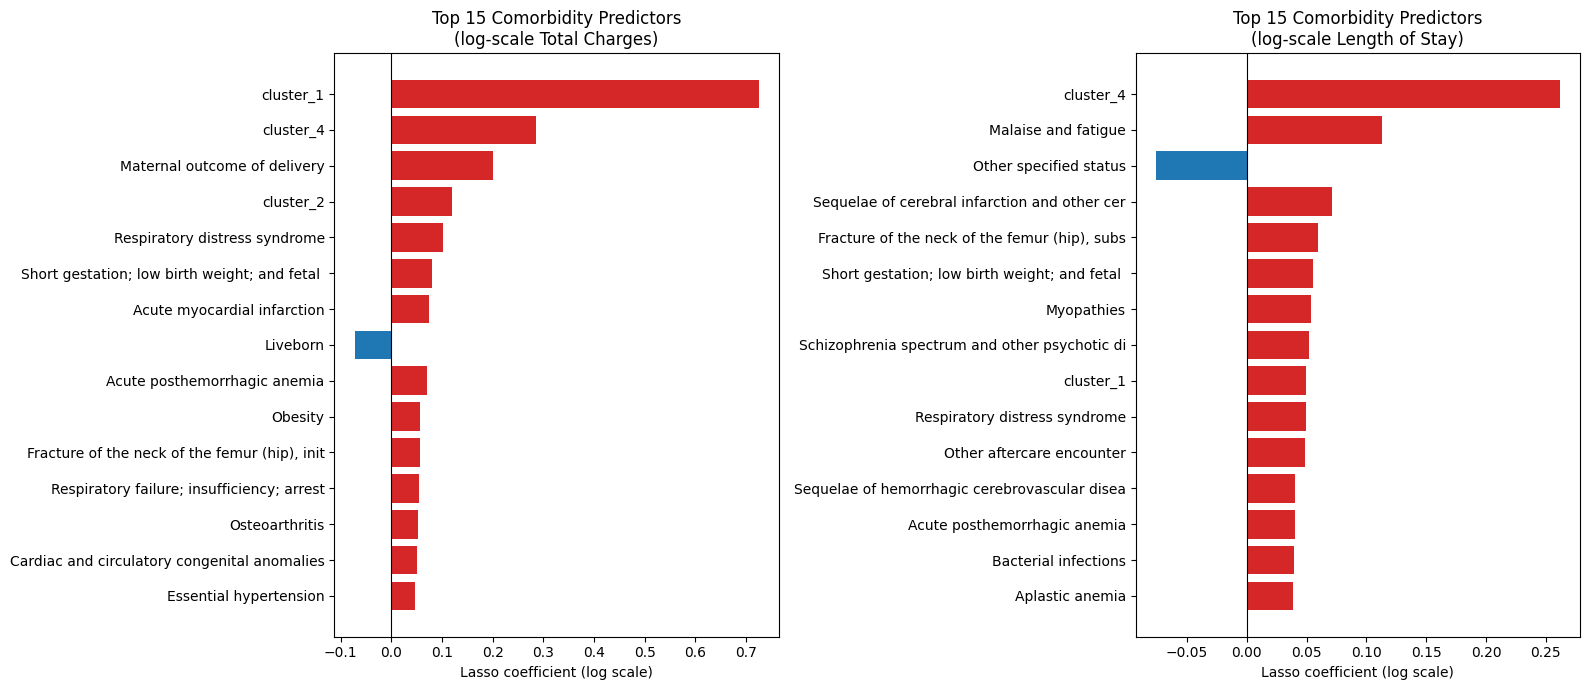


Cluster dummy coefficients — TOTAL_CHARGES:
  feature      coef  cost_multiplier
cluster_1  0.725221         2.065188
cluster_2  0.119862         1.127341
cluster_3 -0.012541         0.987537
cluster_4  0.285670         1.330654

Cluster dummy coefficients — LENGTH_OF_STAY:
  feature      coef  cost_multiplier
cluster_1  0.049810         1.051071
cluster_3 -0.003388         0.996618
cluster_4  0.261663         1.299089

Comorbidities that INCREASE both charges AND LOS (159 found):
  BLD003     Aplastic anemia                                  charges×1.015  LOS×1.039
  BLD004     Acute posthemorrhagic anemia                     charges×1.074  LOS×1.041
  BLD006     Coagulation and hemorrhagic disorders            charges×1.023  LOS×1.018
  BLD010     Other specified and unspecified hematologic c    charges×1.005  LOS×1.000
  CIR001     Chronic rheumatic heart disease                  charges×1.005  LOS×1.006
  CIR005     Myocarditis and cardiomyopathy                   charges×1.034  L

In [ ]:
# ── Step 5: Report — top comorbidity predictors of cost & LOS ───────

def top_predictors(lasso, feature_names, n=15, label='charges'):
    coef_df = pd.DataFrame({
        'feature':         feature_names,
        'coef':            lasso.coef_,
        'cost_multiplier': np.exp(lasso.coef_),   # e^β: multiplicative effect
    })
    # Only non-zero Lasso coefficients
    coef_df = coef_df[coef_df.coef != 0].copy()
    # Attach human-readable descriptions
    coef_df['description'] = coef_df['feature'].apply(
        lambda x: ccsr_desc_fixed.get(x, x)[:45]
    )
    print(f'\n══ Top POSITIVE predictors of {label} ══')
    top_pos = coef_df.nlargest(n, 'coef')[['feature','description','coef','cost_multiplier']]
    print(top_pos.to_string(index=False))
    print(f'\n══ Top NEGATIVE predictors of {label} ══')
    top_neg = coef_df.nsmallest(n, 'coef')[['feature','description','coef','cost_multiplier']]
    print(top_neg.to_string(index=False))
    return coef_df

coef_chg = top_predictors(lasso_chg, feature_names, label='TOTAL_CHARGES')
coef_los = top_predictors(lasso_los, feature_names, label='LENGTH_OF_STAY')

# ── Coefficient comparison plot ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, coef_df, title in zip(axes,
                               [coef_chg, coef_los],
                               ['Total Charges', 'Length of Stay']):
    top15 = coef_df.reindex(coef_df['coef'].abs().nlargest(15).index)
    colors = ['#d62728' if c > 0 else '#1f77b4' for c in top15['coef']]
    ax.barh(top15['description'], top15['coef'], color=colors)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(f'Top 15 Comorbidity Predictors\n(log-scale {title})')
    ax.set_xlabel('Lasso coefficient (log scale)')
    ax.invert_yaxis()

plt.tight_layout()
plt.show()

# ── Cluster label coefficients (does cluster add signal?) ───────────
cluster_coefs_chg = coef_chg[coef_chg.feature.str.startswith('cluster')]
cluster_coefs_los = coef_los[coef_los.feature.str.startswith('cluster')]

print('\nCluster dummy coefficients — TOTAL_CHARGES:')
print(cluster_coefs_chg[['feature','coef','cost_multiplier']].to_string(index=False))
print('\nCluster dummy coefficients — LENGTH_OF_STAY:')
print(cluster_coefs_los[['feature','coef','cost_multiplier']].to_string(index=False))

# ── Summary table ───────────────────────────────────────────────────
shared = set(coef_chg[coef_chg.coef>0]['feature']) & set(coef_los[coef_los.coef>0]['feature'])
print(f'\nComorbidities that INCREASE both charges AND LOS ({len(shared)} found):')
for code in sorted(shared):
    desc = ccsr_desc_fixed.get(code, code)
    c_mult = coef_chg.set_index('feature').loc[code, 'cost_multiplier'] if code in coef_chg.feature.values else '-'
    l_mult = coef_los.set_index('feature').loc[code, 'cost_multiplier']  if code in coef_los.feature.values  else '-'
    mult_c = f'{c_mult:.3f}' if isinstance(c_mult, float) else c_mult
    mult_l = f'{l_mult:.3f}' if isinstance(l_mult, float) else l_mult
    print(f'  {code:<10} {desc[:45]:<47}  charges×{mult_c}  LOS×{mult_l}')
